---
title: "FireIgnition: Lightning, New Fires and Fire Energy with DEFAIR and Machine Learning"
subtitle: "A Destination Earth / DEFAIR use case: from lightning, fuel, rain and fire products to an AI ready cube and a model of lightning ignition over the Iberian Peninsula"
author: "Author: Alejandro Fonseca (EUMETSAT/Starion)"
tags: [DEFAIR, HDA, MTG, LI LFL, FCI GII, LSA SAF, H SAF, CLC+, Machine Learning]
thumbnail: img/EUMETSAT-icon.png
license: MIT
copyright: "© 2026 EUMETSAT"
---

<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/DestinE-DataLake-Lab/DEFAIR/FireIgnition_lightning_using_defair_and_machine_learning.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>

# CONTENTS

## Purpose of this notebook

Every summer, some of the fires that burn across the Iberian Peninsula are lit by lightning. Two
Meteosat Third Generation instruments now watch both ends of that story from the same orbit: the
Lightning Imager records every flash, and the Flexible Combined Imager detects the fires that
appear afterwards. This notebook brings those observations together with the state of the fuel,
the rain that fell with the storm and the atmosphere the storm grew in, turns six products from
four different providers into a single AI ready data cube, and uses that cube to measure whether
lightning is followed by new fires, which conditions make a flash start one, and how much energy
the fires that appear go on to release.

It is also a notebook about extending DEFAIR. Three of the six products have no reader in the
framework, so the first part of the notebook shows how to write one, register it and use it
exactly like the official readers. From there on every source, native or new, goes through the
same DEFAIR calls: read from S3, crop, reproject and align onto one grid.

## Scientific background

Lightning is one of the main natural causes of wildfires, but in the Mediterranean Basin it accounts for
only about 5 % of forest fires. Its weight is larger than that share suggests: lightning fires tend
to start in remote areas and can spread before they are suppressed, and lightning is one of the
main precursors of the largest summer fires. Dry thunderstorms, which bring lightning with little
rain, have been proposed as the main culprits ([Pérez-Invernón et al., 2021](https://doi.org/10.5194/acp-21-17529-2021)). At the same time, only
a very small fraction of flashes start a fire: in Catalonia about one cloud to ground flash in a
thousand ends as a flaming wildfire ([Soler et al., 2021](https://doi.org/10.1071/WF21076)). Since ignition is so rare, the useful
question is not whether lightning can ignite vegetation, **but which conditions turn a flash into an
ignition**.

This analysis builds on the studies that modelled that probability over the Iberian Peninsula.
[Vecín-Arias et al. (2016)](https://doi.org/10.1016/j.agrformet.2016.05.003) combined lightning, vegetation, topography and meteorology with logistic
regression and random forests over the central plateau, and [Rodrigues et al. (2023)](https://doi.org/10.1071/WF22123) trained a machine
learning model on more than 17 million lightning strikes to predict the daily probability of
lightning ignition over the whole peninsula from fuel condition, vegetation and lightning
characteristics. [Pineda and Rigo (2017)](https://doi.org/10.1016/j.agrformet.2017.03.016) examined the role of the rain that falls with the storm, and
the time between the igniting flash and the detection of the fire, the holdover, is usually short:
in the Swiss Alps most igniting strokes occurred less than 24 hours before the fire was detected
([Moris et al., 2020](https://doi.org/10.1016/j.agrformet.2020.107990); [Moris et al., 2023](https://doi.org/10.5194/essd-15-1151-2023) compile holdover times worldwide).

This use case adapts the approach presented in these publications using a new observing system. The MTG Lightning Imager is the first geostationary optical lightning detector imaging Europe ([Enno et al., 2026](https://doi.org/10.5194/egusphere-2026-3386)). It observes total lightning day and night with the same sensor over the whole peninsula, and
describes each flash by its duration and extent, properties that are tested here as possible drivers
of ignition. The Flexible Combined Imager on the same satellite detects the fires every ten minutes,
so lightning and fires are seen from one platform on a common clock. Because the fires are detected
from space, the label is the same on both sides of the border and does not depend on national records
of fire causes. The atmosphere before the storm and the rain that fell with it, two factors behind the
dry thunderstorms linked to the largest fires ([Pineda and Rigo, 2017](https://doi.org/10.1016/j.agrformet.2017.03.016); [Pérez-Invernón et al., 2021](https://doi.org/10.5194/acp-21-17529-2021)),
also come from satellite products. Every input is distributed operationally, and DEFAIR combines them
into a single cube, so the same analysis can be repeated on any new season as soon as the data arrive.

All data sources are satellite products derived and distributed through EUMETSAT and its Satellite Application Facilities: the lightning comes from the MTG Lightning Imager, the fires from the MTG FRP-Pixel product, the fuel from the LSA SAF Fire Risk Map, which applies the Canadian Fire Weather Index System ([Van Wagner, 1987](https://cfs.nrcan.gc.ca/pubwarehouse/pdfs/19927.pdf)) calibrated over Mediterranean Europe with satellite fire
observations ([DaCamara et al., 2014](https://doi.org/10.1071/WF13157)), and the rain from the H SAF.  The full references are listed at the end of the notebook.

This study covers the 37 convective episodes between 14 July and 9 September 2026 over the Iberian
Peninsula on wildland landcover (woody needle leaved trees, broadleaved deciduous trees, broadleaved evergreen trees, shrubs and permanent herbaceous).

## Research questions

**RQ1.** Do wildland cells hit by lightning have a higher probability of a new fire in the following
48 hours than comparable cells without lightning?

**RQ2.** Among the cells hit by lightning, how do the rain of the storm, the instability of the
atmosphere and the dryness of the fuel change that probability?

**RQ3.** Once a new fire has appeared, how much of the energy it releases is explained by the fire
danger and the weather of the episode?

## Hypotheses

RQ1 is answered with the relative risk (RR): the probability of a new fire in cells with lightning
divided by the probability in cells without it.

$$
RR = \frac{P(\text{fire} \mid \text{lightning})}
{P(\text{fire} \mid \text{no lightning})}
$$

- **H0 (null hypothesis):** RR = 1. Cells with and without lightning have the same probability of a new fire.  
$$
P(\text{fire} \mid \text{lightning}) = P(\text{fire} \mid \text{no lightning})
$$
- **H1 (alternative hypothesis):** RR > 1. A new fire is more likely where lightning struck.

H0 is rejected when the whole 95 % interval of the RR lies above 1. An interval that includes 1 is a
valid result, not a failure. RQ2 and RQ3 are exploratory: they estimate the size and direction of each
effect and have no formal hypothesis.

## Data Sources

| Product | Instrument / platform | Source | Format | Variables (units) | Role in the analysis |
|---|---|---|---|---|---|
| [**LI LFL**](https://user.eumetsat.int/resources/user-guides/mtg-li-level-2-data-guide) (Lightning Flashes, Level 2) | Lightning Imager, MTG-I1 | EUMETSAT, DestinE HDA | NetCDF4, one file per 10 minute slot, a list of flashes | `flash_time` (UTC), `latitude`, `longitude` (°), `flash_duration` (ms), `flash_footprint` (number of LI pixels), `number_of_events` (count) | Exposure (was the cell hit?) and storm descriptors |
| [**FCI GII**](https://user.eumetsat.int/resources/user-guides/mtg-fci-l2-gii-data-guide) (Global Instability Indices, Level 2) | Flexible Combined Imager, MTG-I1 | EUMETSAT, DestinE HDA | NetCDF4, one file per 10 minute slot, full disc grid of about 6 km, clear sky only | `k_index` (K), `lifted_index` (K), `prec_water_total` (kg m⁻², equivalent to mm) | Atmosphere before the storm |
| [**LSA-509 FRP-Pixel**](https://lsa-saf.eumetsat.int/en/data/products/fire-products/) | Flexible Combined Imager, MTG-I1 | LSA SAF (IPMA) data service | NetCDF4, one file per 10 minute slot with a fire list and a 1 km quality image, archived as daily Iberian crops | `ACQTIME` (UTC), `LATITUDE_PARALLAX`, `LONGITUDE_PARALLAX` (°), `ABS_LINE`, `ABS_SAMP` (FCI pixel), `FRP` (MW), `qualityflag` (class) | Label (new fire), fire energy and observability |
| [**LSA FRM**](https://lsa-saf.eumetsat.int/en/data/products/fire-products/) (Fire Risk Map, 24 h forecast) | SEVIRI, MSG | EUMETSAT, DestinE HDA | HDF5, one file per day, 3 km | `FWI`, `FFMC`, `DMC`, `DC` (dimensionless codes) | State of the fuel |
| [**H SAF H61B**](https://hsaf.meteoam.it/Products/Detail?prod=H61B) | SEVIRI, MSG | H SAF, official FTP | Gzipped NetCDF, one file per day, full disc at 3 km | `acc_rr` (mm) | Rain that fell with the lightning |
| [**CLC+ Backbone 2023**](https://library.land.copernicus.eu/products/CLCplus_Backbone_2023_PUM_v1.pdf) | Product derived from Sentinel-2 MSI time series | Copernicus Land Monitoring Service -WEkEO | GeoTIFF tiles, 10 m, EPSG:3035 | Eleven land cover classes  | Study area and fuel type |

The raw products were archived once in the project bucket by separate ingestion runs, untouched
except for two datasets: the LSA-509 full disc files were cut to a fixed Iberian window of
rows and columns without transforming any value, and CLC+ was aggregated to the class fractions of
each 10 km cell.

## What the cube contains

The cube has three dimensions: `episode`, and `y`, `x` on a 10 km equal area grid (EPSG:3035). Each cell of each episode is one sample.

An **episode** is one calendar day of the 2026 season, from 00:00 to 24:00 UTC, with significant
lightning over the study area. The Lightning Imager delivers one flash file every ten minutes, 144
per day, so the season was screened cheaply: for each day only three of those files were read, at
13:00, 17:00 and 21:00 UTC, and the day was kept when they held at least 100 flashes over Iberia.
The screen detects active days but does not count their flashes, and a short storm that fell
entirely outside the three sampled slots can be missed. It found 37 episodes between 14 July and 9
September.

| Variable | Meaning |
|---|---|
| `lfl_flash_count` | Number of Lightning Imager flashes whose position falls inside the cell during the episode day. Zero means no flash was recorded |
| `exposed` | True when the cell had at least one flash (`lfl_flash_count > 0`). It separates the two groups compared in RQ1 |
| `lfl_duration_mean` | Mean duration of the flashes of the cell, in ms, as seen from space by the optical sensor |
| `lfl_footprint_mean` | Mean number of Lightning Imager pixels lit by each flash of the cell. Flashes that extend over a larger part of the cloud light more pixels |
| `lfl_events_per_flash` | Mean number of optical events per flash. An event is a single pixel detection of the sensor, so larger or longer flashes produce more of them |
| `gii_k_index` | K index before the storm, in K. It combines the temperature drop between 850 and 500 hPa with the humidity at 850 and 700 hPa; higher values mean a more favourable atmosphere for thunderstorms |
| `gii_lifted_index` | Lifted index before the storm, in K: the temperature of the surrounding air at 500 hPa minus that of a surface air parcel lifted to that level. Negative values mean the lifted air is warmer than its surroundings, so the atmosphere is unstable |
| `gii_prec_water_total` | Total precipitable water before the storm, in kg m⁻², equivalent to mm of water: the depth of liquid water obtained if all the water vapour of the air column condensed. It describes how moist the air mass of the storm is |
| `h61_precip` | Precipitation accumulated in the cell during the episode day, in mm. It measures how much rain fell with the lightning |
| `frm_ffmc` | Fine Fuel Moisture Code, dimensionless: dryness of litter and other fine dead fuels. It indicates the relative ease of ignition and the flammability of fine fuel |
| `frm_dmc` | Duff Moisture Code, dimensionless: an indication of fuel consumption in the moderate duff layers, the loosely compacted organic layers of the forest floor, and in medium size woody material |
| `frm_dc` | Drought Code, dimensionless: the seasonal drought effect on forest fuels, and the amount of smouldering in deep duff layers and large logs |
| `frm_fwi` | Fire Weather Index, dimensionless: the general index of fire danger of the Canadian system, combining the expected rate of spread with the amount of fuel available for combustion. Higher values mean higher danger |
| `lc_needleleaved`, `lc_broadleaved_deciduous`, `lc_broadleaved_evergreen`, `lc_low_woody`, `lc_permanent_herbaceous` | Fraction of the cell, from 0 to 1, covered by each natural CLC+ class: needle leaved trees, broadleaved deciduous trees, broadleaved evergreen trees, shrubs and permanent grassland |
| `lc_trees` | Fraction of the cell covered by trees, the sum of the three tree classes |
| `wildland_fraction` | Fraction of the cell covered by natural vegetation, the sum of the five natural classes |
| `eligible` | True for the cells of the study area: centre inside the study bounding box and at least 50 % natural vegetation |
| `fire_new` | The label. 1 when a new fire was detected in the cell between 00:00 of the episode day and 24:00 of the second day after it, 0 when the cell was observed in that window without any detection, NaN when it was never observable |
| `fire_first` | Time of the first detection of that fire, in seconds since 1970, NaN where there is no fire. It is what identifies the same fire across two episodes whose label windows overlap |
| `fire_repeated` | True when the fire of the cell was already counted in another episode, so this episode does not count it again |
| `frp_sum`, `frp_max` | Sum and maximum of the Fire Radiative Power of every detection of the fire during the label window, in MW. They describe how much energy the fire released and how intense it became |
| `n_det` | Number of detections of the fire during the label window. A fire that keeps burning is seen in more 10 minute slots |
| `burning_before` | True when the cell had a fire detection in the 48 hours before the episode, so any later detection is probably the same fire |
| `observed_slots` | Number of 1 km pixel and 10 minute slot pairs of the cell in which fire detection was possible during the label window. It measures how well the cell was observed |
| `in_sample` | True for the cells used in the analysis: eligible, observable, not burning before, in an episode whose previous 48 hours are covered by the fire archive, and not counting a fire that belongs to another episode |
| `onset` (coordinate) | Time of the episode at which 5 % of the day's flashes over the study area had occurred |
| `prior_complete` (coordinate) | True when the fire archive covers the 48 hours before the episode |

## Assumptions and simplifications

**The sample is a cell in an episode.** A cell is exposed when the Lightning Imager recorded at least
one flash in it during the episode day, from 00:00 to 24:00 UTC. The Lightning Imager observes total
lightning and does not separate cloud to ground strokes from flashes inside the cloud.

**The label window is the same for every cell.** A cell is positive when a new fire is detected
between 00:00 of the episode day and 24:00 of the second day after it, so every flash of the day has
at least 48 hours of follow up. Most igniting strokes precede the detection of their fire by less
than a day, but some fires smoulder or stay hidden under cloud for longer, so the window is set wider
than the typical holdover. A longer window also admits more fires not started by lightning; since
both groups share it, this pushes the relative risk towards 1 rather than inflating it. A detection
earlier on the episode day than the first flash in the cell also counts; the same holds for unexposed
cells, so the comparison is not biased by it.

**Each fire counts once.** Episodes are often consecutive days, and their label windows overlap, so
one fire can fall inside the window of several episodes. It is counted in only one of them: the last
episode whose lightning activity had already started when the fire was first detected, or the first
episode of the overlap when none had. In the other episodes the cell leaves the sample, neither
positive nor negative. Without this rule the same fire would be counted several times, and sometimes
on both sides of the comparison.

**A new fire is one that was not already burning.** A cell with fire detections in the 48 hours before
the episode is taken out of that episode, because a later detection there is more likely the same
fire than a new ignition. An episode whose previous 48 hours are not fully covered by the fire
archive is left out, since that check cannot be made.

**Persistent heat sources are removed.** The FRP-Pixel product has no field telling vegetation
fires from industrial sources. A pixel detected in three or more episodes separated by at least
seven days without detection is treated as a fixed source, because burnt vegetation cannot burn
again weeks later in the same season. Its detections and those of its eight neighbours are
removed. The rule is computed from the same season it filters; it is a fixed property of a pixel,
not of a day, so it carries no information about any particular episode.

**Not observed is not negative.** A cell covered by cloud during the whole label window may have
burned unseen. The label is NaN when the cell had no pixel slot in which fire detection was
possible (quality flag 0, 1 or 2) during the window, and slots missing from the archive count as not
observed.

**Cells are compared with comparable cells.** The relative risk of RQ1 is estimated within strata
defined by the cell and by the amount of rain that fell. A cell is compared with itself in other
episodes, which holds its terrain, its vegetation and its human activity fixed, and only cells with
a similar daily rain accumulation are compared, because the storm that brings the lightning also
brings the rain that can prevent an ignition. The five rain classes are no rain, up to 1 mm, 1 to 5
mm, 5 to 15 mm and more than 15 mm.

**Each variable describes the right moment.** The fuel comes from the 24 hour forecast of the Fire
Risk Map dated on the episode day: it describes the fuel of that day but was computed on the day
before, without knowing the rain of the storm, which would otherwise contaminate it. The
instability indices are only computed under clear sky, and the cells with lightning are cloudy, so
they are taken before the storm: for each pixel, the last clear value between three hours and one
hour before the onset of the lightning activity, the onset being the time when 5 % of the flashes of
the day over the domain had occurred. Precipitation is the accumulation of the episode day.

**Fire energy is a proxy.** RQ3 uses the sum of the Fire Radiative Power of every detection of the
fire during the label window. It is proportional to the energy released only if the fire is observed
regularly, so it is lower for fires hidden under cloud during part of the window and for fires that
start near its end. It is not the time integral of the radiative power.

**Models are trained without class weights.** New fires are rare, and weighting the classes makes a
model search for them at the cost of its probabilities, which can then no longer be read as
probabilities. The models of RQ2 are therefore trained on the observed prevalence, so that the
predicted values and the Brier score keep their meaning.

**Resolution.** Fire pixels on Iberia measure 1.3 to 1.7 km² and are assigned to the cell containing
their parallax corrected centre. Gridded sources are averaged over the area of each 10 km cell. A cell
enters the study when at least 50 of its 100 km² (50%) are natural vegetation (CLC+ classes 2 to 6:
needle leaved, broadleaved deciduous and evergreen trees, shrubs and permanent grassland).
CLC+ describes 2023, three years before the season.

**Association, not causation.** There is no database of fire causes to confirm that a given flash
lit a given fire. The analysis measures a statistical association, not the attribution of single fires.

## How the notebook is organised

The notebook first introduces reader plugins and the three readers written for this case. It then
builds the study grid and the wildland mask, the fire label, and the lightning, atmosphere, fuel and
rain features of each episode, assembles them into the cube and publishes it to the bucket. The
analysis reads the published cube back and answers RQ1 with a stratified relative risk, RQ2 with a
logistic regression and a gradient boosted classifier, and RQ3 with a linear and a gradient boosted
regression, all validated leaving one episode out. Building the 37 episodes takes about half an hour,
so by default (`BUILD_CUBE = False`) the notebook builds one episode live, to show every step, and
then continues with the cube already published in the bucket.

## Prerequisites

Reading is anonymous: the project bucket is public, so no credentials are needed to run the notebook
as it stands. The three new readers live in the `readers` folder next to this notebook, as a small
Python package. It is installed once, together with the two machine learning libraries of the
analysis, scikit-learn and XGBoost, after which the kernel must be restarted so that DEFAIR can
discover the readers. Rebuilding and republishing the cube (BUILD_CUBE = True) is the only step that writes, and it needs the DataLake S3 keys; **anyone can instead rebuild it into their own store by changing BUCKET and S3_ENDPOINT in the configuration**.

In [1]:
%pip install --quiet -e readers scikit-learn xgboost

/home/eouser/projects/DEFAIR/fireignition/.venv-rc3/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from defair.logging import setup_logging            
from defair.plugin_manager import list_readers, load_reader, load_source
from defair_data.core import Dataset
from defair_data.data_reader_plugin import DataReaderPlugin
from defair_ops.transformations.alignment import AlignmentPlugin
from defair_ops.transformations.reprojection import ReferenceGrid

import os
import time
import inspect
from dotenv import load_dotenv
from pathlib import Path
from getpass import getpass

import boto3
from botocore import UNSIGNED
from botocore.client import Config
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from affine import Affine
from pyproj import CRS, Transformer
from scipy.stats import spearmanr
from IPython.display import Code, display

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import average_precision_score, brier_score_loss, r2_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import DMatrix, XGBClassifier, XGBRegressor

import warnings
warnings.filterwarnings("ignore", message="Consolidated metadata is currently not part")   # harmless Zarr 3 notice

setup_logging(log_level="ERROR")   # keeps the output readable; use "INFO" to inspect the pipeline

In [3]:
# Use case configuration

# Convective episodes of the 2026 season: days with at least 100 flashes over Iberia in the season scan.
# The scan found 37
EPISODES = ["2026-07-14", "2026-07-15", "2026-07-16", "2026-07-17", "2026-07-19",
            "2026-07-20", "2026-07-24", "2026-07-25", "2026-07-30", "2026-08-01", "2026-08-03",
            "2026-08-04", "2026-08-06", "2026-08-07", "2026-08-08", "2026-08-09", "2026-08-10",
            "2026-08-11", "2026-08-12", "2026-08-13", "2026-08-14", "2026-08-15", "2026-08-16",
            "2026-08-17", "2026-08-19", "2026-08-20", "2026-08-22", "2026-08-23", "2026-08-24",
            "2026-08-26", "2026-08-27", "2026-08-31", "2026-09-01", "2026-09-02", "2026-09-05",
            "2026-09-06", "2026-09-09"]
DEMO_EPISODE = "2026-08-10"

# Study area and grid: EPSG:3035 at 10 km, 130 x 100 cells
BBOX = [-10.0, 36.0, 4.0, 44.0]                       # lon_min, lat_min, lon_max, lat_max
MARGIN = 2.0                                          # degrees kept around the bbox when cropping
X0, Y1, CELL, NX, NY = 2_600_000, 2_500_000, 10_000, 130, 100
FACTOR = 10                                           # gridded sources are aligned at 1 km, then averaged 10 x 10
GRID_1KM = ReferenceGrid(crs="EPSG:3035", transform=Affine(CELL / FACTOR, 0.0, X0, 0.0, -CELL / FACTOR, Y1),
                         width=NX * FACTOR, height=NY * FACTOR)
SPATIAL_METHOD = "nearest"                            # the area average over each 10 km cell is taken after alignment

# Decisions of the study design (see Assumptions)
WILDLAND_MIN_FRACTION = 0.5                           # at least 50 of the 100 km2 are natural vegetation
LABEL_DAYS, PRIOR_DAYS = 3, 2                         # label from D 00:00 to D+2 24:00; 48 h before D
ONSET_QUANTILE = 0.05                                 # onset: 5 % of the day's flashes have occurred
GII_FROM, GII_TO = pd.Timedelta(hours=3), pd.Timedelta(hours=1)
PERSISTENT_GAP_DAYS, PERSISTENT_MIN_EPISODES = 7, 3
OBSERVED_CLASSES = [0, 1, 2]                          # quality flags where fire detection was possible

# Analysis
RAIN_BINS = [-np.inf, 0, 1, 5, 15, np.inf]            # rain classes, in mm, used as strata together with the cell
RAIN_LABELS = ["0", "0-1", "1-5", "5-15", ">15"]
STRATA = ["cell", "rain_class"]                       # a cell is compared with itself under similar rain
FEATURES = ["h61_precip", "gii_k_index", "gii_lifted_index", "gii_prec_water_total",
            "frm_ffmc", "frm_dmc", "frm_dc", "frm_fwi",
            "lfl_flash_count", "lfl_duration_mean", "lfl_footprint_mean", "lfl_events_per_flash", "lc_trees"]
FEATURES_ALL = ["h61_precip", "gii_k_index", "gii_lifted_index", "gii_prec_water_total",
                "frm_ffmc", "frm_dmc", "frm_dc", "frm_fwi", "lfl_flash_count", "lc_trees"]
N_BOOT = 200                                          # bootstrap resamples of episodes: relative risk, effects
SEED = 0

# Local workspace and cube location
ROOT = Path.cwd()                                     # the folder of this notebook
CUBE_DIR = ROOT / "data" / "fireignition"
CUBE_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_CUBE = CUBE_DIR / "fireignition_cube.zarr"
CUBE_KEY = "cubes/fireignition_cube.zarr/"
BUILD_CUBE = False                                    # True rebuilds the 37 episodes and republishes the cube (about 30 min)

In [4]:
# S3 access

#=====================================================================================
# S3 object store: edit these three lines to point at a different store!!

S3_ENDPOINT = "https://s3.central.data.destination-earth.eu"
BUCKET      = "defair-use-case"
PREFIX      = ""   # source prefixes and cubes/ live at the bucket root
#=====================================================================================

# The bucket is public for reading, so every read in this notebook is anonymous
S3_SOURCE_KWARGS = {"anon": True, "endpoint_url": S3_ENDPOINT}
READ = {"source": "s3", "source_kwargs": S3_SOURCE_KWARGS}
STORAGE_OPTIONS = {"anon": True, "client_kwargs": {"endpoint_url": S3_ENDPOINT}}

s3 = boto3.client("s3", endpoint_url=S3_ENDPOINT, config=Config(signature_version=UNSIGNED))

s3_write = None
if BUILD_CUBE:                                        # writing is the only step that needs keys
    load_dotenv(ROOT / ".env")
    s3_write = boto3.client("s3", endpoint_url=S3_ENDPOINT,
                            aws_access_key_id=os.environ.get("S3_ACCESS_KEY") or getpass("S3 access key: "),
                            aws_secret_access_key=os.environ.get("S3_SECRET_KEY") or getpass("S3 secret key: "))

In [5]:
# Object listing and the location of each raw product in the bucket

paginator = s3.get_paginator("list_objects_v2")   # pagination is mandatory on DestinE (buckets over 1000 objects)
def s3_keys(prefix):
    """All object keys under a prefix, paginated."""
    return sorted(o["Key"] for p in paginator.paginate(Bucket=BUCKET, Prefix=PREFIX + prefix)
                  for o in p.get("Contents", []))

def frm_path(day):
    d = pd.Timestamp(day)
    return f"s3://{BUCKET}/{PREFIX}frm-orig/{d:%Y-%m-%d}/S-LSA_-HDF5_LSASAF_MSG_FRM-F024_Euro_{d:%Y%m%d}1200"

def h61_path(day):
    sealed = pd.Timestamp(day) + pd.Timedelta(days=1)      # the accumulation of day D is sealed at D+1 00:00
    return f"s3://{BUCKET}/{PREFIX}precip-orig/h61_{sealed:%Y%m%d}_0000_24_fdk.nc.gz"

def lsa_path(day):
    return f"s3://{BUCKET}/{PREFIX}lsa509-iberia/LSA509_iberia_{pd.Timestamp(day):%Y%m%d}.nc"

# DEFAIR Reader plugins

## What is a reader?

DEFAIR does not open product files directly. Instead, it uses a **reader**, a small plugin that understands the structure of a specific file format and converts its contents into an `xarray.Dataset`.

A reader is a Python class that inherits from `DataReaderPlugin` and implements a single method, `read()`. This is the only requirement. The base class provides the rest of the functionality, including `self.open_file(path, source, source_kwargs)`. This method opens the requested file regardless of where it is stored, whether on a local disk, in an S3 bucket, or in the HDA.

Because `open_file()` handles the storage layer, the reader does not need to manage credentials, storage protocols, or file downloads. The same reader code can therefore be used to read a local file or an object stored in a bucket.

## What does a reader enable?

Once a product has a reader, it can be handled by DEFAIR like any other supported product. This includes:

- streaming data directly from S3,
- reading multiple files,
- cropping,
- reprojection, and
- spatial alignment.

An alternative would be to convert the product outside DEFAIR and import the resulting arrays. However, this approach would bypass these capabilities. DEFAIR ships with **built-in readers** for the METOP, MTG, Sentinel-3, MSG native and ERA5 families, among others. For any other source, you can write your **own reader** and register it as a plugin. Once registered,
the framework treats it exactly like a built-in one.

Implementing a reader requires only a small amount of code, after which the product can be processed by DEFAIR in the same way as products with built-in readers.

## Which sources in this case need a reader?

In this case, two of the six sources are already supported by built-in readers, while three require custom readers:

| Source | Reader |
|---|---|
| MTG Lightning Imager flashes | `mtg_li_lfl`, built in |
| MTG instability indices | `mtg_l2_gii`, built in |
| LSA SAF Fire Risk Map | None, implemented in this notebook |
| LSA SAF FRP-Pixel | None, implemented in this notebook |
| H SAF precipitation | None, implemented in this notebook |
| CLC+ land cover | Not needed, as it is already provided in aggregated form |

## Building a reader step by step: the Fire Risk Map

This section builds the reader of the LSA SAF Fire Risk Map from scratch, one step at a time. Each
step adds one piece to the same reader and is checked on the same file, the Fire Risk Map of the demo
episode. The file holds five variables: the four codes of the Canadian system (`FWI`, `FFMC`, `DMC`,
`DC`) and the danger class (`Risk`). The Fire Weather Index, `FWI`, is used to follow the changes from
one step to the next. At the end the pieces are put together in one class, which is exactly the
`lsa_frm` reader of the `readers` package, which is then registered and called by its name, like any
built-in reader.

### Step 1: open the file

The first version of the reader does only one thing: open the file and hand its contents to xarray.
The reader is a class, `FRMReader`, that inherits from `DataReaderPlugin`, the base class of every
DEFAIR reader. It needs just one method, `read()`, which receives the path of the file and returns
its contents.

Inside `read()`, two lines do the work. The first, `self.open_file`, is provided by DEFAIR: it finds
the file wherever it is stored, here in the project bucket, so the reader never deals with
credentials or downloads. The second opens that file with xarray, with two options that matter for
this format. `phony_dims="sort"` gives names to the dimensions, because the HDF5 file does not
include any. `mask_and_scale=False` keeps the values exactly as they are stored, so that we can see
the raw content before transforming it.

Finally, `load_reader` turns the class into a working reader without installing or registering
anything, which is the quickest way to test a reader while it is being written. The last line shows
one of the variables it returns, the Fire Weather Index.

In [6]:
class FRMReader(DataReaderPlugin):
    """Fire Risk Map reader, step 1: open the file through DEFAIR's source layer."""

    def read(self, path, source=None, source_kwargs=None):
        f = self.open_file(path, source, source_kwargs)
        return xr.open_dataset(f, engine="h5netcdf", phony_dims="sort", mask_and_scale=False)

reader = load_reader("frm_step1", plugin_class=FRMReader, fresh=True)
raw = reader.read(frm_path(DEMO_EPISODE), **READ)
raw["FWI"]

<xarray.DataArray 'FWI' (phony_dim_0: 651, phony_dim_1: 1701)> Size: 2MB
[1107351 values with dtype=int16]
Dimensions without coordinates: phony_dim_0, phony_dim_1
Attributes:
    CAL_OFFSET:      999.0
    CAL_SLOPE:       999.0
    MISSING_VALUE:   -8000
    NB_BYTES:        2
    N_COLS:          1701
    N_LINES:         651
    OFFSET:          0.0
    PRODUCT:         FWI
    PRODUCT_ID:      999
    SCALING_FACTOR:  100.0
    UNITS:           Dimensionless

The file is read, but it is not usable yet. The Fire Weather Index is stored as 16 bit integers, a
value of `2345` meaning 23.45, with `-8000` marking pixels without data. The dimensions have no
names (`phony_dim_0`, `phony_dim_1`) and no coordinates, so nothing says where on Earth each pixel
is, and there is no time. A model fed with this would learn from numbers a hundred times too large
and from a sea filled with -8000, and the field could not be combined with any other source. The next
three steps fix each of these problems.

### Step 2: physical values

The LSA SAF stores each variable as an integer `X` with attributes of its own, and defines the
physical value as `X / SCALING_FACTOR + OFFSET`, with `MISSING_VALUE` for pixels without data (LSA SAF, *Product Output Format*, SAF/LAND/IPMA/POF/1.2, available in the
[LSA SAF documentation repository](https://nextcloud.lsasvcs.ipma.pt/s/CjtrxjMcYBz5wT7?dir=/PUM-Product_User_Manual)). Those names are not part of the CF
conventions, the metadata standard that xarray, DEFAIR and most EO tools understand, so no tool
applies them. The reader does not do the arithmetic itself: it translates the attributes into their
CF equivalents, `scale_factor = 1 / SCALING_FACTOR` (CF multiplies where the LSA SAF divides),
`add_offset` and `_FillValue`, and lets the standard decoder, `xr.decode_cf`, produce the physical
values. This is the same conversion the LSA SAF applies when it publishes its own NetCDF files. The five variables are loaded, the dimensions get their usual names, `y` for
rows and `x` for columns, and each variable is also told which grid mapping describes its
projection, `geostationary`, which is added in step 4.

In [7]:
VARIABLES = ["FWI", "FFMC", "DMC", "DC", "Risk"]
ds = raw[VARIABLES].load()

ds = ds.rename({"phony_dim_0": "y", "phony_dim_1": "x"})
for v in VARIABLES:
    a = ds[v].attrs
    ds[v].attrs = {
        "scale_factor": np.float32(1 / a["SCALING_FACTOR"]),
        "add_offset": np.float32(a["OFFSET"]),
        "_FillValue": np.int16(a["MISSING_VALUE"]),
        "long_name": a["PRODUCT"],
        "units": "1",
        "grid_mapping": "geostationary",
    }
ds = xr.decode_cf(ds)

fwi = ds["FWI"]
print(f"FWI {fwi.dtype}: from {float(fwi.min()):.2f} to {float(fwi.max()):.2f}, "
      f"{float(fwi.isnull().mean()):.1%} of the pixels without data")

FWI float32: from 0.00 to 149.07, 61.3% of the pixels without data


The values are now physical: decimal numbers on the scale of the index, and the pixels without data,
the sea and the space around the Earth, are `NaN` instead of -8000.

### Step 3: georeference

After step 2 the values are right, but the pixels still have no position on Earth. Three ideas give
them one.

**The disc.** Every SEVIRI product is a cut of the same image, the full disc that the satellite sees
from its fixed point above the equator. The geometry of that image is standard and public: its size
in pixels, its extent in metres in the view of the satellite, and its projection, which describes the
position and height of the satellite and the shape of the Earth. The size of the disc, its projection and the pixel that marks its centre are defined by EUMETSAT in
the MSG Level 1.5 Image Data Format Description ([EUM/MSG/ICD/105](https://user.eumetsat.int/s3/eup-strapi-media/pdf_ten_05105_msg_img_data_e7c8b315e6.pdf)); its extent in metres is taken from the same definition as implemented in the satpy library, area
`msg_seviri_fes_3km` ([satpy area definitions](https://github.com/pytroll/satpy/blob/main/satpy/etc/areas.yaml)).

**The window.** The Fire Risk Map is not the full disc but a window over Europe and North Africa.
The file says where that window sits, following the CGMS navigation standard of EUMETSAT: its
attributes `COFF` and `LOFF` are the column and the row of the window where the centre of the disc
falls, counted from 1. Since the centre of the full disc is always the same pixel, the row and
column where the window starts follow by subtraction. Nothing is measured or assumed: the two numbers
come from the header of the file.

**The coordinates.** With the start of the window and the size of a pixel, the position of the centre
of every column, `x`, and every row, `y`, is a sum. The projection is written in `GEOS_ATTRS` in CF
form, so that any tool can compute the latitude and longitude of any pixel from `x` and `y`.

The check below draws the Fire Weather Index on its new coordinates and outlines the study area,
converted from longitude and latitude to the same projection. The outline must frame the Iberian
Peninsula.

COFF = 308, LOFF = 1808: the window starts at column 1549 and row 49 of the full disc


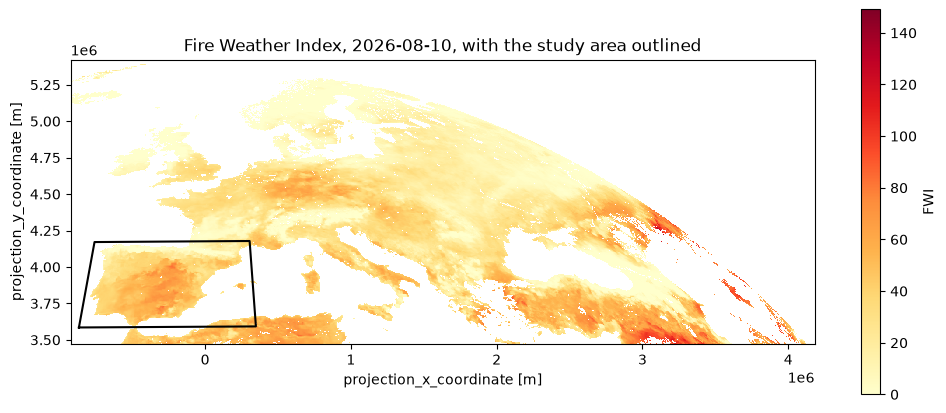

In [8]:
# The disc: the standard SEVIRI full disc at 3 km (area msg_seviri_fes_3km)
DISK_SIZE = 3712
DISK_EXTENT = (-5570248.686685662, -5567248.28340708, 5567248.28340708, 5570248.686685662)
GEOS_ATTRS = {
    "grid_mapping_name": "geostationary",
    "longitude_of_projection_origin": 0.0,
    "latitude_of_projection_origin": 0.0,
    "perspective_point_height": 35785831.0,
    "sweep_angle_axis": "y",
    "semi_major_axis": 6378169.0,
    "semi_minor_axis": 6356583.8,
    "false_easting": 0.0,
    "false_northing": 0.0,
}

# The window: where the Fire Risk Map starts within the disc, from the CGMS attributes of the file
coff, loff = int(raw.attrs["COFF"]), int(raw.attrs["LOFF"])   # window column and row of the disc centre, counted from 1
centre = DISK_SIZE // 2                                        # the same disc centre in the full disc, counted from 0
col0, row0 = centre - (coff - 1), centre - (loff - 1)
print(f"COFF = {coff}, LOFF = {loff}: the window starts at column {col0} and row {row0} of the full disc")

# The coordinates: the centre of every column and row, in metres, in the view of the satellite
dx = (DISK_EXTENT[2] - DISK_EXTENT[0]) / DISK_SIZE
x = DISK_EXTENT[0] + (col0 + np.arange(ds.sizes["x"]) + 0.5) * dx
y = DISK_EXTENT[3] - (row0 + np.arange(ds.sizes["y"]) + 0.5) * dx
ds = ds.assign_coords(
    x=("x", x, {"standard_name": "projection_x_coordinate", "units": "m", "axis": "X"}),
    y=("y", y, {"standard_name": "projection_y_coordinate", "units": "m", "axis": "Y"}),
)

# Check: the study area, converted to the same projection, must frame the Iberian Peninsula
to_geos = Transformer.from_crs("EPSG:4326", CRS.from_cf(GEOS_ATTRS), always_xy=True)
bx, by = to_geos.transform([BBOX[0], BBOX[2], BBOX[2], BBOX[0], BBOX[0]],
                           [BBOX[1], BBOX[1], BBOX[3], BBOX[3], BBOX[1]])
fig, ax = plt.subplots(figsize=(12, 5))
ds["FWI"].plot(ax=ax, cmap="YlOrRd", cbar_kwargs={"label": "FWI"})
ax.plot(bx, by, color="black")
ax.set_aspect("equal")
ax.set_title(f"Fire Weather Index, {DEMO_EPISODE}, with the study area outlined")
plt.show()

### Step 4: time and metadata

After step 3 every pixel has a position on Earth, but the dataset still does not say when it was
observed. This step adds the date and completes the description of the dataset.

- **The date.** The file stores its date in the global attribute `IMAGE_ACQUISITION_TIME`. The reader
reads it and turns it into a `time` dimension with a single value. This is what later lets DEFAIR
stack the files of different days along time. In the notebook the date is called `acquired`, because
`time` is already the name of a Python module used further down.

- **The projection.** In step 2 every variable was told that its projection is described by a variable
called `geostationary`. That variable is created now, as a coordinate: it holds no data, only the
attributes of the projection defined in step 3. It has to be a coordinate because that is where the
reprojection tools used by DEFAIR look for the projection of each variable.

- **The description.** Finally, the global attributes record what the dataset is and where it comes
from.

In [9]:
acquired = pd.to_datetime(str(raw.attrs["IMAGE_ACQUISITION_TIME"]), format="%Y%m%d%H%M%S")
ds = ds.expand_dims(time=[acquired])
ds = ds.assign_coords(geostationary=xr.DataArray(np.int32(0), attrs=GEOS_ATTRS))
ds.attrs = {
    "Conventions": "CF-1.8",
    "source": "LSA SAF Fire Risk Map, MSG SEVIRI Euro window",
    "time_range": raw.attrs["TIME_RANGE"],
    "nominal_product_time": str(raw.attrs["NOMINAL_PRODUCT_TIME"]),
}
ds

<xarray.Dataset> Size: 22MB
Dimensions:        (time: 1, y: 651, x: 1701)
Coordinates:
  * time           (time) datetime64[us] 8B 2026-08-10T12:00:00
  * y              (y) float64 5kB 5.422e+06 5.419e+06 ... 3.474e+06 3.471e+06
  * x              (x) float64 14kB -9.211e+05 -9.181e+05 ... 4.177e+06 4.18e+06
    geostationary  int32 4B 0
Data variables:
    FWI            (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
    FFMC           (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
    DMC            (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
    DC             (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
    Risk           (time, y, x) float32 4MB nan nan nan nan ... nan nan nan nan
Attributes:
    Conventions:           CF-1.8
    source:                LSA SAF Fire Risk Map, MSG SEVIRI Euro window
    time_range:            Daily,Fc-024
    nominal_product_time:  202608090801

### Step 5: the complete reader

Steps 1 to 4 covered everything the reader does with the data: open the file, convert the values,
place the pixels on Earth and add the date. Written one after the other inside a single `read()`
method, those four steps are the reader. The cell below prints it as it is stored in the `readers`
package, under the name `lsa_frm`.

Three small additions turn the four steps into a plugin that DEFAIR can drive on its own.

**It recognises its own files.** When DEFAIR is given a path without being told which reader to use,
it asks every installed reader the same question through the method `can_handle`: can you open this
one? Most readers answer by looking at the extension of the file. Fire Risk Map files have no
extension, so this one answers by the shape of the name.

**It lets the user choose the variables.** The `read()` method takes an argument called `variables`.
Someone who only needs the Fire Weather Index asks for it alone, and the rest is never loaded.
Without that argument, the reader loads the five variables of step 2.

**It declares what kind of data it returns.** The method `_build_cdm` writes a short description of
the geometry, called the Common Data Model. Here it says: this is a grid on a geostationary
projection, the same declaration the built-in SEVIRI and FCI readers make. DEFAIR reads that
declaration to decide what it may do with the source. A grid can be reprojected and resampled onto a
target grid. A list of points, such as the fire detections, cannot: it travels through untouched,
because turning points into a grid means counting or averaging them, and that choice belongs to the
user. This is why, further down, the notebook counts the flashes and the fire detections into the
cells itself.

What `read()` returns is a DEFAIR `Dataset`: the data and that declaration travelling together. Its
arrays are lazy, which means they are described but not loaded until a computation needs their
values, so an archive larger than the memory of the machine can still be opened and processed.

In [10]:
import lsa_readers.lsa_frm
Code(inspect.getsource(lsa_readers.lsa_frm), language="python")

import re
from os import PathLike
from typing import Any, ClassVar

import numpy as np
import pandas as pd
import xarray as xr

from defair_data.cdm import CommonDataModel, GeostationaryParams, GriddedModel
from defair_data.core import Dataset
from defair_data.data_reader_plugin import DataReaderPlugin

# The disc: the standard SEVIRI full disc at 3 km (satpy area msg_seviri_fes_3km)
DISK_SIZE = 3712
DISK_EXTENT = (-5570248.686685662, -5567248.28340708, 5567248.28340708, 5570248.686685662)
GEOS_ATTRS = {
    "grid_mapping_name": "geostationary",
    "longitude_of_projection_origin": 0.0,
    "latitude_of_projection_origin": 0.0,
    "perspective_point_height": 35785831.0,
    "sweep_angle_axis": "y",
    "semi_major_axis": 6378169.0,
    "semi_minor_axis": 6356583.8,
    "false_easting": 0.0,
    "false_northing": 0.0,
}


class LSAFRMReaderPlugin(DataReaderPlugin):
    """Reader for the LSA SAF MSG Fire Risk Map (FRM), Euro window, HDF5."""

    PRIORITY: ClassVar[int] = 60
    FILENAME_PATTERN: ClassVar[re.Pattern] = re.compile(r"LSASAF_MSG_FRM-F\d{3}_Euro_\d{12}$")
    DEFAULT_VARIABLES: ClassVar[list[str]] = ["FWI", "FFMC", "DMC", "DC", "Risk"]

    @classmethod
    def can_handle(cls, path: str | PathLike) -> bool:
        return bool(cls.FILENAME_PATTERN.search(str(path)))

    def read(
        self,
        path: str | PathLike,
        source: str | None = None,
        source_kwargs: dict[str, Any] | None = None,
        variables: list[str] | None = None,
    ) -> Dataset:
        variables = variables or self.DEFAULT_VARIABLES
        with self.open_file(path, source, source_kwargs) as f:
            raw = xr.open_dataset(f, engine="h5netcdf", phony_dims="sort", mask_and_scale=False)
            ds = raw[variables].load()

        ds = ds.rename({"phony_dim_0": "y", "phony_dim_1": "x"})
        for v in variables:
            a = ds[v].attrs
            ds[v].attrs = {
                "scale_factor": np.float32(1 / a["SCALING_FACTOR"]),
                "add_offset": np.float32(a["OFFSET"]),
                "_FillValue": np.int16(a["MISSING_VALUE"]),
                "long_name": a["PRODUCT"],
                "units": "1",
                "grid_mapping": "geostationary",
            }
        ds = xr.decode_cf(ds)

        # The window: where this file starts within the disc, from its CGMS attributes
        coff, loff = int(raw.attrs["COFF"]), int(raw.attrs["LOFF"])   # window column and row of the disc centre, counted from 1
        centre = DISK_SIZE // 2                                        # the same disc centre in the full disc, counted from 0
        col0, row0 = centre - (coff - 1), centre - (loff - 1)

        # The coordinates: the centre of every column and row, in metres, in the view of the satellite
        dx = (DISK_EXTENT[2] - DISK_EXTENT[0]) / DISK_SIZE
        x = DISK_EXTENT[0] + (col0 + np.arange(ds.sizes["x"]) + 0.5) * dx
        y = DISK_EXTENT[3] - (row0 + np.arange(ds.sizes["y"]) + 0.5) * dx
        ds = ds.assign_coords(
            x=("x", x, {"standard_name": "projection_x_coordinate", "units": "m", "axis": "X"}),
            y=("y", y, {"standard_name": "projection_y_coordinate", "units": "m", "axis": "Y"}),
        )

        time = pd.to_datetime(str(raw.attrs["IMAGE_ACQUISITION_TIME"]), format="%Y%m%d%H%M%S")
        ds = ds.expand_dims(time=[time])
        ds = ds.assign_coords(geostationary=xr.DataArray(np.int32(0), attrs=GEOS_ATTRS))
        ds.attrs = {
            "Conventions": "CF-1.8",
            "source": "LSA SAF Fire Risk Map, MSG SEVIRI Euro window",
            "time_range": raw.attrs["TIME_RANGE"],
            "nominal_product_time": str(raw.attrs["NOMINAL_PRODUCT_TIME"]),
        }
        return Dataset(ds.chunk(), cdm=self._build_cdm(variables))

    @staticmethod
    def _build_cdm(variables: list[str]) -> CommonDataModel:
        grid = GriddedModel(
            id="lsa_frm_grid",
            variables=tuple(variables),
            crs="GEOS",
            dims=("y"

### Step 6: registering the reader

Up to here the reader has been used through `load_reader`, which builds it straight from the class
written in this notebook. That is enough to test a reader, and only that. The call used everywhere
else in the notebook, `Dataset.from_source`, is the one that reads a single file, a list of files or
a whole archive from S3, and it does not receive a class: it receives a **name**. For a name to work,
DEFAIR has to be able to find the class behind it.

Python has a standard mechanism for exactly this, called **entry points**. An installed package can
publish a list of names under a group, and any other package can ask Python what that group contains.
DEFAIR looks in the group `defair_data.readers`.

The `readers` folder next to this notebook is a small installable package, and its `pyproject.toml`
publishes the three readers of this case in that group. Installing the package, as done in the
Prerequisites, is therefore the whole registration: nothing has to be declared inside the notebook,
and the same three readers become available to any other notebook of the environment.

One practical detail: Python reads the entry points when the interpreter starts, so a reader
installed while the kernel is already running is only found after restarting the kernel.

The cell below prints the `pyproject.toml` and asks DEFAIR for the readers it knows, filtered to the
three of this case.

In [11]:
import lsa_readers

pyproject = Path(lsa_readers.__file__).parents[1] / "pyproject.toml"
display(Code(pyproject.read_text(), language="toml"))
[name for name in list_readers() if name in ("lsa_frm", "lsa509_frp", "hsaf_h61")]

[project]
name = "lsa-readers"
version = "0.1.0"
requires-python = ">=3.12"

[project.entry-points."defair_data.readers"]
lsa_frm = "lsa_readers.lsa_frm:LSAFRMReaderPlugin"
lsa509_frp = "lsa_readers.lsa509_frp:LSA509FRPReaderPlugin"
hsaf_h61 = "lsa_readers.hsaf_h61:HSAFH61ReaderPlugin"

[build-system]
requires = ["hatchling"]
build-backend = "hatchling.build"

['hsaf_h61', 'lsa509_frp', 'lsa_frm']

Once registered, the reader is used like any built-in one: `Dataset.from_source` receives the path of
the file and the name of the reader, and returns the Fire Risk Map ready to use, with physical values,
coordinates and time. This is how every Fire Risk Map file is read from here on.

In [12]:
fire_risk = Dataset.from_source(frm_path(DEMO_EPISODE), reader="lsa_frm", **READ)
fire_risk.data

<xarray.Dataset> Size: 22MB
Dimensions:        (time: 1, y: 651, x: 1701)
Coordinates:
  * time           (time) datetime64[us] 8B 2026-08-10T12:00:00
  * y              (y) float64 5kB 5.422e+06 5.419e+06 ... 3.474e+06 3.471e+06
  * x              (x) float64 14kB -9.211e+05 -9.181e+05 ... 4.177e+06 4.18e+06
    geostationary  int32 4B 0
Data variables:
    FWI            (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
    FFMC           (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
    DMC            (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
    DC             (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
    Risk           (time, y, x) float32 4MB dask.array<chunksize=(1, 651, 1701), meta=np.ndarray>
Attributes:
    Conventions:           CF-1.8
    source:                LSA SAF Fire Risk Map, MSG SEVIRI Euro window
    time_range:            Daily,Fc-024
    nominal_product_time:  202608090801
    defair_cdm:            {"schema_version":3,"reader":"lsa_frm","product_fa...

## The other two readers

Besides the Fire Risk Map, two more products of this case needed a reader: the FRP-Pixel product and
the H SAF precipitation, read by `lsa509_frp` and `hsaf_h61`. They were built with the same steps as
the Fire Risk Map reader, they are registered in the same package, and their code is in the `readers`
folder.

One difference matters for what follows. Each FRP-Pixel file holds two products with different
shapes: a list of fire detections, one row per fire, and a quality image that says where fire
detection was possible. A reader returns one dataset, so `lsa509_frp` returns one product at a time,
chosen with the parameter `product`: `"fires"` for the detections and `"quality"` for the image.

With the three readers registered, every product reads like any other DEFAIR source: one
`Dataset.from_source` call, straight from the bucket, with the reader named and nothing else. The
cell below reads one file from each of them, and prints four lines rather than three because the
FRP-Pixel reader is called twice, once for each of its two products.

In [13]:
samples = {
    "FRM":             Dataset.from_source(frm_path(DEMO_EPISODE), reader="lsa_frm", **READ),
    "H61B":            Dataset.from_source(h61_path(DEMO_EPISODE), reader="hsaf_h61", **READ),
    "LSA-509 fires":   Dataset.from_source(lsa_path(DEMO_EPISODE), reader="lsa509_frp", product="fires", **READ),
    "LSA-509 quality": Dataset.from_source(lsa_path(DEMO_EPISODE), reader="lsa509_frp", product="quality", **READ),
}
for name, ds_sample in samples.items():
    print(f"{name:16s} {dict(ds_sample.data.sizes)}")

FRM              {'time': 1, 'y': 651, 'x': 1701}
H61B             {'time': 1, 'y': 3712, 'x': 3712}
LSA-509 fires    {'fire': 4889}
LSA-509 quality  {'time': 144, 'y': 836, 'x': 1384}


# The study grid and the wildland mask

**One grid for every source.** Every source of the cube ends on the same grid: EPSG:3035, the equal
area projection of the European Environment Agency, with cells of 10 km, 130 columns by 100 rows. In
an equal area grid every cell has the same surface, which matters because flashes and fires are
counted per cell. The grid is fixed in advance as a `ReferenceGrid`, so every run produces exactly
the same cells.

**The land cover of each cell.** The land cover was already brought to this grid during ingestion:
for every cell, the file holds the number of 10 m CLC+ pixels of each class. Dividing by the million
pixels of a full cell gives the fraction of the cell covered by each class. The sea belongs to none of
the eleven classes, so in a coastal cell the fractions add up to less than one.

**The study area.** A cell enters the study when two conditions hold. First, at least half of it, 50
of its 100 km², is natural vegetation. This keeps the cells dominated by forest, shrubs and
grassland, and leaves out those dominated by crops, where many fires are agricultural burns that
would look like ignitions. Second, its centre lies inside the study bounding box, because the
rectangular grid reaches beyond the box at its corners, where the land cover was not downloaded.

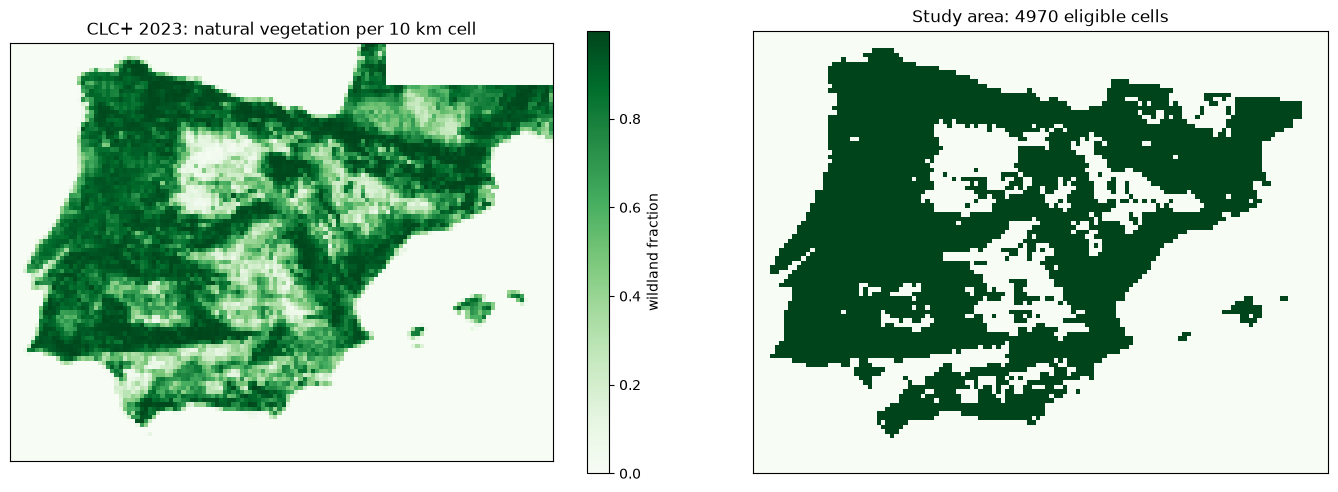

In [14]:
# The aggregated land cover: how many 10 m CLC+ pixels of each class fall in every 10 km cell
with load_source("s3", **S3_SOURCE_KWARGS).open(f"s3://{BUCKET}/{PREFIX}aux/landcover_10km_2023.npz") as f:
    lc = dict(np.load(f))

# The centre of every column and row of the study grid, and the fraction of the cell covered by each class
X = X0 + CELL * (np.arange(NX) + 0.5)
Y = Y1 - CELL * (np.arange(NY) + 0.5)
fraction = lc["counts"] / (CELL / 10) ** 2
classes = {2: "needleleaved", 3: "broadleaved_deciduous", 4: "broadleaved_evergreen",
           5: "low_woody", 6: "permanent_herbaceous"}
static = xr.Dataset({f"lc_{name}": (("y", "x"), fraction[list(lc["classes"]).index(c)])
                     for c, name in classes.items()}, coords={"x": X, "y": Y})
static["wildland_fraction"] = sum(static[v] for v in list(static.data_vars))
static["lc_trees"] = static.lc_needleleaved + static.lc_broadleaved_deciduous + static.lc_broadleaved_evergreen

# The study area: enough natural vegetation, and the centre of the cell inside the bounding box
cx, cy = np.meshgrid(X, Y)
clon, clat = Transformer.from_crs("EPSG:3035", "EPSG:4326", always_xy=True).transform(cx, cy)
in_bbox = (clon >= BBOX[0]) & (clon <= BBOX[2]) & (clat >= BBOX[1]) & (clat <= BBOX[3])
static["eligible"] = (("y", "x"), in_bbox & (static.wildland_fraction.values >= WILDLAND_MIN_FRACTION))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
static.wildland_fraction.plot(ax=axes[0], cmap="Greens", cbar_kwargs={"label": "wildland fraction"})
static.eligible.plot(ax=axes[1], cmap="Greens", add_colorbar=False)
axes[0].set_title("CLC+ 2023: natural vegetation per 10 km cell")
axes[1].set_title(f"Study area: {int(static.eligible.sum())} eligible cells")
for ax in axes:
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()

# The label: new fires in the FRP-Pixel product

**Detections are not fires.** The FRP-Pixel product records detections: a hot pixel in one 10 minute
slot. A fire that burns for three days appears in hundreds of slots, and a fixed industrial heat
source, such as a gas flare or a steelworks, appears again and again through the whole season. The
product has no field saying which is which, so the fixed sources are found by their own recurrence:
for every pixel of the FCI grid, the days with detections are grouped into periods of activity
separated by at least seven days without any, and a pixel with three or more such periods is treated
as a fixed source. A vegetation fire burns out its fuel and does not come back to the same pixel
weeks later, whereas an industrial source lights up over and over. The detections of a fixed source
and of its eight neighbours are removed. The rule works on the FCI pixel and not on the 10 km cell,
so that two different fires falling in the same cell are never mixed.

**Observed is not the same as empty.** A cell without detections only counts as "no fire" if the
satellite could have seen a fire there. For every 1 km pixel and every 10 minute slot, the quality
image of the product says whether fire detection was possible: values 0, 1 and 2 mean it was, while
cloud, sun glint, a failed background estimate or invalid input mean it was not. The second cell
below counts, for each day and each 10 km cell, how many pixel slots were observable. The quality
image has its own geostationary grid, so each of its pixels is placed into its 10 km cell once, from
the projection the reader wrote in the `geostationary` variable.

**The label of one episode** then follows from the two windows of the study design. The label window
runs from 00:00 of the episode day to 24:00 of the second day after it, and the prior window covers
the 48 hours before the episode day. A cell is positive when it has a detection in the label window,
negative when it was observed at least once in that window without any detection, and not observable
otherwise. A cell with a detection in the prior window is flagged as `burning_before`, and an episode
whose prior window is not fully covered by the archive is flagged too, because that check cannot be
made there. For every positive cell the last cell also keeps the time of the first detection, which
identifies the fire, and the Fire Radiative Power of the fire, which describes how much energy it
released.

In [15]:
# Every detection of the season, read in one call
lsa_keys = s3_keys("lsa509-iberia/")
LSA_DAYS = {pd.Timestamp(k[-11:-3]) for k in lsa_keys}

fires = Dataset.from_source([f"s3://{BUCKET}/{k}" for k in lsa_keys], reader="lsa509_frp",
                            product="fires", concat_dim="fire", **READ).data
det = pd.DataFrame({"line": fires.ABS_LINE.values.astype(int), "samp": fires.ABS_SAMP.values.astype(int),
                    "time": pd.to_datetime(fires.ACQTIME.values), "frp": fires.FRP.values,
                    "lon": fires.LONGITUDE_PARALLAX.values, "lat": fires.LATITUDE_PARALLAX.values})

# For every FCI pixel, its days of activity are grouped into periods separated by a week without detections
days = det.assign(day=det.time.dt.normalize())[["line", "samp", "day"]].drop_duplicates().sort_values(["line", "samp", "day"])
gap = days.groupby(["line", "samp"]).day.diff().dt.days
days["episode"] = (gap.isna() | (gap >= PERSISTENT_GAP_DAYS)).groupby([days.line, days.samp]).cumsum()
recurrence = days.groupby(["line", "samp"]).episode.max()

# A pixel that lights up in three such periods is a fixed source: it and its eight neighbours are dropped
sources = recurrence[recurrence >= PERSISTENT_MIN_EPISODES].index.to_frame(index=False)
neighbourhood = pd.concat([sources + [dl, ds_] for dl in (-1, 0, 1) for ds_ in (-1, 0, 1)]).drop_duplicates()
keep = ~pd.MultiIndex.from_frame(det[["line", "samp"]]).isin(pd.MultiIndex.from_frame(neighbourhood))

print(f"{len(det)} detections on {len(LSA_DAYS)} days | {len(sources)} fixed source pixels | "
      f"{int((~keep).sum())} detections removed")
det = det[keep].reset_index(drop=True)

171685 detections on 64 days | 76 fixed source pixels | 6227 detections removed


In [16]:
# From longitude and latitude to the 10 km grid: the two functions used for every point product
to_laea = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)

def to_cell(lon, lat):
    """Index of the 10 km cell containing each position (row * NX + col), -1 outside the grid."""
    fx, fy = to_laea.transform(lon, lat)
    col = np.floor((fx - X0) / CELL).astype(int)
    row = np.floor((Y1 - fy) / CELL).astype(int)
    return np.where((col >= 0) & (col < NX) & (row >= 0) & (row < NY), row * NX + col, -1)

def cell_mask(cells):
    """Boolean (y, x) grid, True in the given cells."""
    grid = np.zeros(NY * NX, bool)
    grid[cells[cells >= 0]] = True
    return grid.reshape(NY, NX)

det["cell"] = to_cell(det.lon.values, det.lat.values)   # the cell of every detection, computed once

In [17]:
# Each pixel of the quality image is placed in its 10 km cell once, from the projection written by the reader
quality = samples["LSA-509 quality"].data
geos = CRS.from_cf(quality["geostationary"].attrs)
qx, qy = np.meshgrid(quality.x.values, quality.y.values)
pixel_cell = to_cell(*Transformer.from_crs(geos, "EPSG:4326", always_xy=True).transform(qx, qy)).ravel()
inside = pixel_cell >= 0
cell_pixels = np.bincount(pixel_cell[inside], minlength=NX * NY)   # fire pixels per cell, used in the analysis

def observed_slots(day):
    """Observed pixel slots per cell on one day of the fire archive."""
    flags = Dataset.from_source(lsa_path(day), reader="lsa509_frp", product="quality", **READ).data.qualityflag
    n = flags.isin(OBSERVED_CLASSES).sum("time").values.ravel()
    return np.bincount(pixel_cell[inside], weights=n[inside], minlength=NX * NY).reshape(NY, NX)

# One pass over the whole fire archive: how much of each cell was observable on each day
observed = {day: observed_slots(day) for day in sorted(LSA_DAYS)}

In [18]:
def label_episode(day):
    """Label, fire identity and energy, prior fire and observability of every cell for one episode."""
    d = pd.Timestamp(day)
    # The two windows of the design: detections that count as the label, and those that come before
    window = det[det.time.between(d, d + pd.Timedelta(days=LABEL_DAYS), inclusive="left")].query("cell >= 0")
    before = det.time.between(d - pd.Timedelta(days=PRIOR_DAYS), d, inclusive="left")
    slots = sum(observed.get(t, 0) for t in pd.date_range(d, periods=LABEL_DAYS))

    # For every cell with a fire: when it was first seen, and how much energy it released
    fire = cell_mask(window.cell.values)
    by_cell = window.groupby("cell").agg(fire_first=("time", "min"), frp_sum=("frp", "sum"),
                                         frp_max=("frp", "max"), n_det=("frp", "size"))
    by_cell["fire_first"] = by_cell.fire_first.values.astype("int64") / 1e9   # seconds since 1970
    layers = {}
    for name, values in by_cell.items():
        grid = np.full(NY * NX, np.nan)
        grid[values.index] = values.values
        layers[name] = grid.reshape(NY, NX)

    # A cell is positive with a detection, negative if it was observed without one, and NaN if never observable
    return {
        "fire_new": np.where(fire, 1.0, np.where(slots > 0, 0.0, np.nan)),
        "burning_before": cell_mask(det.cell.values[before]),
        "observed_slots": np.asarray(slots, float) * np.ones((NY, NX)),
        "prior_complete": all(t in LSA_DAYS for t in pd.date_range(d - pd.Timedelta(days=PRIOR_DAYS), periods=PRIOR_DAYS)),
        **layers,
    }

# The features of an episode

**Lightning.** The Lightning Flashes product comes as one file per 10 minute slot, 144 per day, and
each file is a list of flashes with the time, position and properties of every one of them. The files
are read one by one with the DEFAIR reader for LI point products and joined into a single table,
which is the approach that works reliably for this kind of product. Only the flashes of the episode
day inside the study area are kept, and they are counted into the 10 km cells. Three things come out
of them: the exposure, which is whether the cell had at least one flash; the storm descriptors of
each cell, which are the number of flashes and their mean duration, footprint and number of optical
events; and the onset of the episode, the moment when 5 % of the flashes over the study area had
occurred, which marks when the real activity begins so that one isolated flash early in the morning
does not move it.

**The atmosphere before the storm.** The instability indices of the GII are computed only under clear
sky, because the satellite measures the radiation coming up from the surface and the air, and a cloud
blocks it. During the storm the cells with lightning are under thick cloud, so the GII is taken
before it: every 10 minute slot between three hours and one hour before the onset is read, and for
each pixel the last clear value is kept. Each GII file leaves a different set of pixels without
latitude and longitude, so the positions of all the slots are joined first and the result is cropped
once, to the study area with a margin. The result describes the atmosphere the storm grew in, which
is what tells a wet storm, whose rain can prevent an ignition, from a dry one. GII files are named
with a cycle number, the index of the 10 minute slot within the day, and the pattern anchors it
between underscores so that it cannot match digits of the timestamps.

**Fuel and rain, and the alignment.** The Fire Risk Map, the precipitation and the pre storm GII each
give one field per episode, and they arrive on three different grids: the SEVIRI window of the Fire
Risk Map, the full SEVIRI disc of H61B and the FCI grid of the GII. A single DEFAIR alignment call
reprojects the three onto the same grid and merges them into one dataset. Before that, each source is
stamped with the date of the episode, because all three describe the same episode but each product
writes its date in its own way.

**Why an average, and how it is obtained.** A 10 km cell holds about eleven SEVIRI pixels of 3 km,
and a storm can cover only a few of them, so the value of the cell should be the average of all the
pixels inside it rather than the value at its centre. DEFAIR's alignment offers nearest neighbour,
bilinear and cubic resampling onto a projected grid, and all three estimate the value at the centre
of each target cell. The average is therefore reached in two steps. The sources are first aligned
onto a 1 km version of the study grid with nearest neighbour, which copies each source pixel onto the
fine cells it covers, and blocks of 10 by 10 fine cells are then averaged into each 10 km cell. The
result is the average of the source pixels over the cell, each one weighted by the part of the cell
it covers, and where part of a cell has no data, at the coast or in a gap of a source, only the fine
cells with data enter the average. The alignment adds the name of its product in front of each
variable, so the variables are picked by the end of their name.

In [19]:
# Lightning: the flashes of the episode day, counted and described in every cell
LFL_FIELDS = ["flash_time", "longitude", "latitude", "flash_duration", "flash_footprint", "number_of_events"]

def read_flashes(day):
    """All flashes of the episode day inside the study area, as a table."""
    # The 144 slots of the day are read one by one: the multifile concatenation degenerates on point products
    tables = []
    for key in s3_keys(f"lfl-orig/{day}/"):
        f = Dataset.from_source(f"s3://{BUCKET}/{key}", reader="mtg_li_lfl", **READ).data
        tables.append(pd.DataFrame({v: np.ravel(f[v].values) for v in LFL_FIELDS}))
    fl = pd.concat(tables, ignore_index=True)
    # One slot starts before midnight, so the flashes are cut to the calendar day and to the study area
    d = pd.Timestamp(day)
    fl = fl[fl.flash_time.between(d, d + pd.Timedelta(days=1), inclusive="left")]
    return fl[fl.longitude.between(BBOX[0], BBOX[2]) & fl.latitude.between(BBOX[1], BBOX[3])]

def lightning_features(fl):
    """Storm descriptors of every cell: count, duration, footprint and events per flash."""
    g = fl.assign(cell=to_cell(fl.longitude.values, fl.latitude.values)).query("cell >= 0").groupby("cell")
    stats = pd.DataFrame({"lfl_flash_count": g.size(),
                          "lfl_duration_mean": g.flash_duration.mean(),
                          "lfl_footprint_mean": g.flash_footprint.mean(),
                          "lfl_events_per_flash": g.number_of_events.mean()})
    # A cell without flashes counts zero of them, but has no duration or footprint to describe
    out = {}
    for name, values in stats.items():
        grid = np.full(NY * NX, 0.0 if name == "lfl_flash_count" else np.nan)
        grid[values.index] = values.values
        out[name] = grid.reshape(NY, NX)
    return out

In [20]:
# Atmosphere: the instability indices of the last clear sky before the storm
CROP = {"lat_min": BBOX[1] - MARGIN, "lat_max": BBOX[3] + MARGIN,
        "lon_min": BBOX[0] - MARGIN, "lon_max": BBOX[2] + MARGIN}
GII_VARS = ["k_index", "lifted_index", "prec_water_total"]

def gii_before_onset(day, onset):
    """Last clear GII value per pixel between 3 h and 1 h before the onset, as a DEFAIR Dataset."""
    d = pd.Timestamp(day)
    slots = pd.date_range((onset - GII_FROM).floor("10min"), (onset - GII_TO).floor("10min"), freq="10min")
    last_clear = lat = lon = None
    # Slot after slot, every pixel keeps the most recent value it had under clear sky
    for s in slots[slots >= d]:
        cycle = f"{(s - d) // pd.Timedelta(minutes=10) + 1:04d}"
        try:
            gii_ds = Dataset.from_source(f"s3://{BUCKET}/{PREFIX}gii-orig/{d:%Y%m%d}/*_{cycle}_????.nc",
                                         reader="mtg_l2_gii", **READ)
        except FileNotFoundError:
            continue                                        # slot missing from the archive
        g = gii_ds.transform("content_filter", include_vars=GII_VARS).data.isel(time=0, drop=True)
        lat = g.lat if lat is None else lat.fillna(g.lat)   # each file leaves a different set of pixels without position
        lon = g.lon if lon is None else lon.fillna(g.lon)
        g = g.drop_vars(["lat", "lon"])
        last_clear = g if last_clear is None else g.where(g.notnull(), last_clear)
    if last_clear is None:
        return None                                         # no GII slot available before the onset
    # The crop comes last, on the positions joined from every slot, so that all of them share one window
    inside_crop = ((lat >= CROP["lat_min"]) & (lat <= CROP["lat_max"]) &
                   (lon >= CROP["lon_min"]) & (lon <= CROP["lon_max"])).values
    rows, cols = np.flatnonzero(inside_crop.any(axis=1)), np.flatnonzero(inside_crop.any(axis=0))
    window = {"y": slice(rows[0], rows[-1] + 1), "x": slice(cols[0], cols[-1] + 1)}
    last_clear = last_clear.assign_coords(lat=lat, lon=lon).isel(window)
    return Dataset(last_clear.expand_dims(time=[d]))

In [21]:
# Fuel, rain and atmosphere: three grids brought onto one, and averaged into the 10 km cells
GRIDDED = {"frm_fwi": "FWI", "frm_ffmc": "FFMC", "frm_dmc": "DMC", "frm_dc": "DC",
           "h61_precip": "acc_rr",
           "gii_k_index": "k_index", "gii_lifted_index": "lifted_index", "gii_prec_water_total": "prec_water_total"}

def pick(ds_aligned, suffix):
    """The variable whose name ends with suffix, or NaN everywhere if the source was not available."""
    match = [v for v in ds_aligned.data_vars if v.endswith(suffix)]
    return ds_aligned[match[0]].values if match else np.full((NY, NX), np.nan)

def gridded_features(day, gii):
    """FRM, H61B and the pre storm GII of one episode, aligned at 1 km and averaged into the 10 km cells."""
    d = pd.Timestamp(day)
    # The three products describe the same episode but each writes its date differently
    stamp = lambda source: Dataset(source.data.assign_coords(time=[d]))
    frm = stamp(Dataset.from_source(frm_path(day), reader="lsa_frm", **READ))
    h61 = stamp(Dataset.from_source(h61_path(day), reader="hsaf_h61", **READ))
    # One call brings the three grids onto the fine grid; the 10 x 10 average then gives the cell mean
    with AlignmentPlugin() as plugin:
        fine = plugin.transform(frm, target=GRID_1KM, datasets=[h61] + ([gii] if gii else []),
                                spatial_method=SPATIAL_METHOD).data.isel(time=0, drop=True)
    aligned = fine.coarsen(x=FACTOR, y=FACTOR).mean().compute()
    assert np.allclose(aligned.x, X) and np.allclose(aligned.y, Y)
    return {name: pick(aligned, suffix) for name, suffix in GRIDDED.items()}

# Building the cube

The builder puts the pieces together for one episode: the flashes give the exposure, the descriptors
and the onset; the onset fixes the GII window; the alignment brings fuel, rain and atmosphere onto the
grid; and the label comes from the cleaned fire detections. Every piece ends as a (y, x) array, so the
episode is a plain xarray dataset with one extra dimension, `episode`, of length one.

## The builder, live

The cell below builds one episode from the raw products, exactly as every episode of the campaign is
built, and shows the result.

In [22]:
def build_episode(day):
    """The cube of one episode: every source on the 10 km grid, one (x,y) layer per variable."""
    d = pd.Timestamp(day)
    fl = read_flashes(day)
    onset = fl.flash_time.quantile(ONSET_QUANTILE)
    label = label_episode(day)
    prior_complete = label.pop("prior_complete")
    layers = gridded_features(day, gii_before_onset(day, onset)) | lightning_features(fl) | label
    ep = xr.Dataset({name: (("y", "x"), values) for name, values in layers.items()}, coords={"x": X, "y": Y})
    ep["exposed"] = ep.lfl_flash_count > 0
    return ep.expand_dims(episode=[d]).assign_coords(onset=("episode", [onset]),
                                                     prior_complete=("episode", [prior_complete]))

t0 = time.time()
demo = build_episode(DEMO_EPISODE)
print(f"{DEMO_EPISODE} built in {time.time() - t0:.0f} s")
demo

2026-08-10 built in 45 s


<xarray.Dataset> Size: 2MB
Dimensions:               (episode: 1, y: 100, x: 130)
Coordinates:
  * episode               (episode) datetime64[us] 8B 2026-08-10
    onset                 (episode) datetime64[ns] 8B 2026-08-10T11:33:41.212...
    prior_complete        (episode) bool 1B True
  * y                     (y) float64 800B 2.495e+06 2.485e+06 ... 1.505e+06
  * x                     (x) float64 1kB 2.605e+06 2.615e+06 ... 3.895e+06
Data variables: (12/20)
    frm_fwi               (episode, y, x) float32 52kB nan nan ... 63.67 55.56
    frm_ffmc              (episode, y, x) float32 52kB nan nan ... 97.01 96.19
    frm_dmc               (episode, y, x) float32 52kB nan nan ... 359.4 307.1
    frm_dc                (episode, y, x) float32 52kB nan nan ... 858.6 838.2
    h61_precip            (episode, y, x) float64 104kB 0.0 0.0 ... 7.266 8.478
    gii_k_index           (episode, y, x) float32 52kB 11.3 11.32 ... 28.27
    ...                    ...
    observed_slots        (episode, y, x) float64 104kB 0.0 0.0 ... 1.908e+04
    fire_first            (episode, y, x) float64 104kB nan nan nan ... nan nan
    frp_sum               (episode, y, x) float64 104kB nan nan nan ... nan nan
    frp_max               (episode, y, x) float64 104kB nan nan nan ... nan nan
    n_det                 (episode, y, x) float64 104kB nan nan nan ... nan nan
    exposed               (episode, y, x) bool 13kB False False ... False False

## The campaign run

The same builder runs once per episode, and each finished episode is written to its own Zarr store on
disk. An episode already on disk is skipped, so the loop can be interrupted and resumed at no cost.

**The cube is already built.** Building the 37 episodes takes about half an hour, and publishing the
result needs write access to the bucket. The cube of this study has therefore been built once and
published at `s3://defair-use-case/cubes/fireignition_cube.zarr`. By default, with `BUILD_CUBE = False`
in the configuration, the notebook skips the campaign, the consolidation and the upload, and continues
with the published cube. The demo episode above shows exactly how each of its episodes was built. Set
`BUILD_CUBE = True` to rebuild the whole cube from the raw products.

In [23]:
if BUILD_CUBE:
    for day in EPISODES:
        store = CUBE_DIR / f"episode_{day}.zarr"
        if store.exists():
            continue
        t0 = time.time()
        build_episode(day).to_zarr(store, mode="w")
        print(f"{day}  {time.time() - t0:.0f} s")
else:
    print("BUILD_CUBE is False: the campaign is skipped and the published cube is used")

BUILD_CUBE is False: the campaign is skipped and the published cube is used


# Consolidation

The episode cubes are joined along `episode`, and the land cover layers, which do not change from one
episode to the next, are added once.

**One fire, one episode.** Episodes are often consecutive days, and a label window of three days
therefore overlaps the window of the next episode. A fire that starts inside the overlap falls in the
window of both, and without a rule it would be counted twice, sometimes once as a cell with lightning
and once as a cell without it. Each fire is identified by the time of its first detection in the cell,
and it is given to one episode only: the last one whose lightning activity had already started when
the fire was first seen, since a fire can only follow a storm that has begun, and the most recent
storm is the closest candidate. When no episode had started yet, the fire stays with the first episode
that sees it. In every other episode the cell leaves the sample, neither positive nor negative.

The final selection is stored in the cube as `in_sample`, so that no consumer has to rebuild it: an
eligible wildland cell, observable during the label window, not burning before the episode, in an
episode whose prior window is complete, and not counting a fire that belongs to another episode. With
`BUILD_CUBE = False` this cell is skipped and the published cube, which holds exactly this result, is
read further down.

In [24]:
# Consolidation: the 37 episodes in one cube, and each fire given to a single episode
def repeated_fires(cube):
    """True where the fire of the cell was already counted in another episode of the sample."""
    t = cube.fire_first.where(cube.in_sample).to_dataframe().dropna(subset=["fire_first"]).reset_index()
    onset = pd.Series(pd.to_datetime(cube.onset.values).astype("int64") / 1e9,
                      index=pd.to_datetime(cube.episode.values))
    t["started"] = onset.loc[pd.to_datetime(t.episode)].values <= t.fire_first
    owner = (t.groupby(["y", "x", "fire_first"])[["episode", "started"]]
             .apply(lambda g: g.episode[g.started].max() if g.started.any() else g.episode.min())
             .rename("owner").reset_index())
    dup = t.merge(owner, on=["y", "x", "fire_first"]).query("episode != owner")

    mask = np.zeros(cube.fire_new.shape, bool)
    mask[pd.Index(cube.episode.values).get_indexer(dup.episode),
         pd.Index(cube.y.values).get_indexer(dup.y),
         pd.Index(cube.x.values).get_indexer(dup.x)] = True
    return xr.DataArray(mask, coords=cube.fire_new.coords, dims=cube.fire_new.dims)

if BUILD_CUBE:
    cube = xr.concat([xr.open_zarr(CUBE_DIR / f"episode_{d}.zarr") for d in EPISODES], dim="episode")
    cube = xr.merge([cube, static]).load()
    cube["in_sample"] = (cube.eligible & ~cube.burning_before & cube.prior_complete & cube.fire_new.notnull())
    cube["fire_repeated"] = repeated_fires(cube)
    cube["in_sample"] = cube.in_sample & ~cube.fire_repeated

    print(dict(cube.sizes))
    print(f"episodes with a complete prior window: {int(cube.prior_complete.sum())} of {cube.sizes['episode']}")
    print(f"distinct fires: {int((cube.fire_new == 1).where(cube.in_sample).sum())}, "
          f"repeated: {int(cube.fire_repeated.sum())}")
else:
    print("BUILD_CUBE is False: the consolidation is skipped")

BUILD_CUBE is False: the consolidation is skipped


# Publication

With `BUILD_CUBE = True`, the consolidated cube is written to local disk and uploaded to the bucket
one file at a time; otherwise nothing is uploaded. The next cell then closes the loop the way any
consumer of the data starts: it reads the published cube straight from S3 with a single `open_zarr`
call. Everything below the publication works only with that cube, so the analysis never depends on
the pipeline that produced it.

Any user can open the same cube outside this notebook with that one call:

```python
cube = xr.open_zarr("s3://defair-use-case/cubes/fireignition_cube.zarr",
                    storage_options={"anon": True,
                                     "client_kwargs": {"endpoint_url": "https://s3.central.data.destination-earth.eu"}})
```

In [25]:
if BUILD_CUBE:
    for v in cube.variables:
        cube[v].encoding = {}
    cube.to_zarr(LOCAL_CUBE, mode="w")

    t0 = time.time()
    n = 0
    try:
        for root, _, files in os.walk(LOCAL_CUBE):
            for f in files:
                path = os.path.join(root, f)
                s3_write.upload_file(path, BUCKET, PREFIX + CUBE_KEY + os.path.relpath(path, LOCAL_CUBE))
                n += 1
    except Exception:
        raise PermissionError(f"the cube was built but could not be uploaded to {BUCKET}: this account "
                              f"has read access only. It is saved locally at {LOCAL_CUBE}.")
    print(f"{n} objects uploaded in {time.time() - t0:.0f} s")
else:
    print("BUILD_CUBE is False: nothing to upload, the published cube is read below")

BUILD_CUBE is False: nothing to upload, the published cube is read below


In [26]:
cube = xr.open_zarr(f"s3://{BUCKET}/{PREFIX}{CUBE_KEY}", storage_options=STORAGE_OPTIONS).load()
print(dict(cube.sizes))
print(f"{len(cube.data_vars)} variables: {', '.join(cube.data_vars)}")

{'episode': 37, 'y': 100, 'x': 130}
30 variables: burning_before, eligible, exposed, fire_first, fire_new, fire_repeated, frm_dc, frm_dmc, frm_ffmc, frm_fwi, frp_max, frp_sum, gii_k_index, gii_lifted_index, gii_prec_water_total, h61_precip, in_sample, lc_broadleaved_deciduous, lc_broadleaved_evergreen, lc_low_woody, lc_needleleaved, lc_permanent_herbaceous, lc_trees, lfl_duration_mean, lfl_events_per_flash, lfl_flash_count, lfl_footprint_mean, n_det, observed_slots, wildland_fraction


## One grid, every source

The figure stacks the layers of the most active episode of the season as planes over the same 10 km
footprint, bottom to top: the land cover that defines the study area, the fuel, the rain, the
atmosphere before the storm, the lightning and, on top, the new fires that followed. Each plane is
coloured by its own range. Eight layers from six products and four providers, and the cells line up
exactly, because they are the same cells: that alignment is the whole point of the cube, and it is
what makes the question of this study answerable at all.

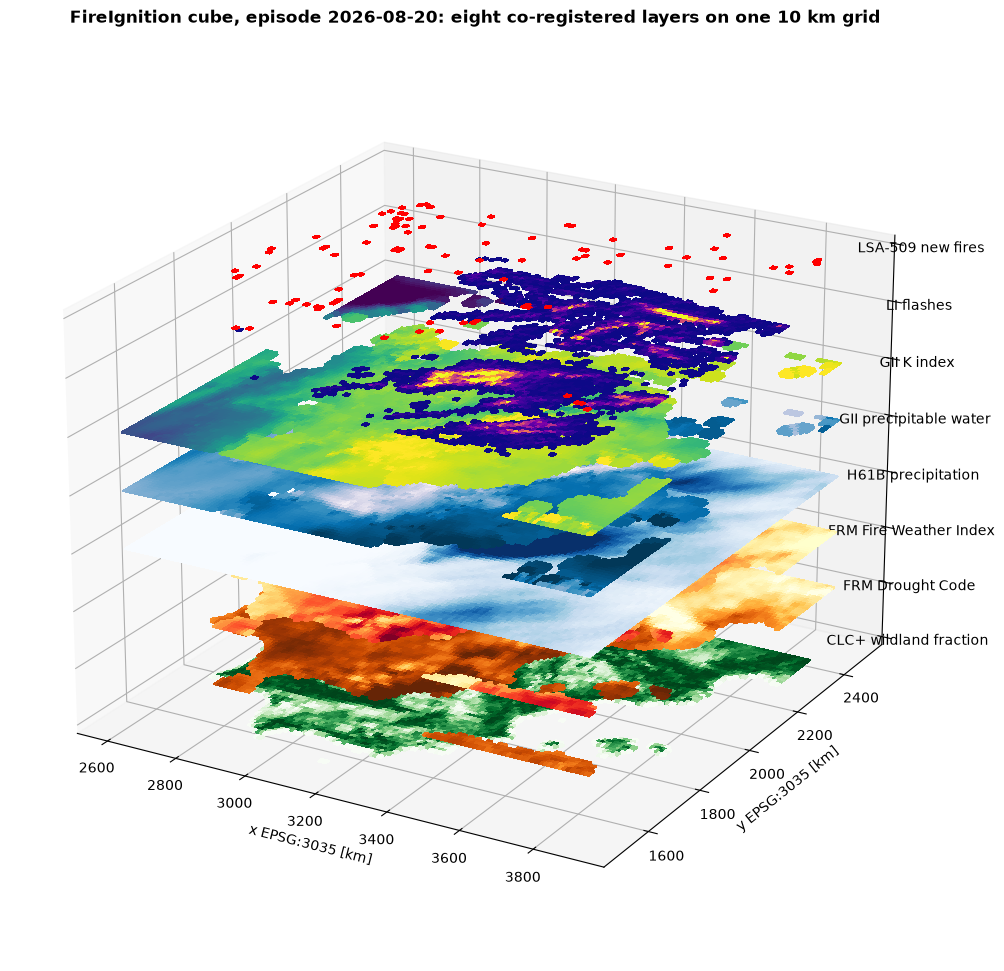

In [27]:
showcase = cube.lfl_flash_count.sum(("y", "x")).idxmax("episode").values
ep = cube.sel(episode=showcase)
layers = [
    ("CLC+ wildland fraction", cube.wildland_fraction.where(cube.wildland_fraction > 0), "Greens"),
    ("FRM Drought Code", ep.frm_dc, "YlOrBr"),
    ("FRM Fire Weather Index", ep.frm_fwi, "YlOrRd"),
    ("H61B precipitation", ep.h61_precip, "Blues"),
    ("GII precipitable water", ep.gii_prec_water_total, "PuBu"),
    ("GII K index", ep.gii_k_index, "viridis"),
    ("LI flashes", ep.lfl_flash_count.where(ep.lfl_flash_count > 0), "plasma"),
    ("LSA-509 new fires", ep.fire_new.where(ep.fire_new == 1), "autumn"),
]

xs, ys = np.meshgrid(cube.x / 1000, cube.y / 1000)
fig = plt.figure(figsize=(12, 13))
ax = fig.add_subplot(projection="3d")
for z, (name, field, cmap) in enumerate(layers):
    data = field.values.astype(float)
    valid = data[np.isfinite(data)]
    if valid.size == 0:
        continue
    norm = mcolors.Normalize(*np.percentile(valid, [2, 98]))
    colors = plt.get_cmap(cmap)(norm(data))
    colors[~np.isfinite(data)] = 0                      # transparent where there is no data
    ax.plot_surface(xs, ys, np.full(xs.shape, z), facecolors=colors,
                    rstride=1, cstride=1, shade=False, antialiased=False)

ax.set_zticks(range(len(layers)))
ax.set_zticklabels([name for name, *_ in layers])
ax.set_xlabel("x EPSG:3035 [km]")
ax.set_ylabel("y EPSG:3035 [km]")
ax.set_title(f"FireIgnition cube, episode {str(showcase)[:10]}: eight co-registered layers on one 10 km grid",
             fontweight="bold")
ax.view_init(elev=22, azim=-60)
plt.show()

# Analysis

From here on the notebook works only with the published cube, read back from the bucket above,
exactly as any user of the data would start. The cube is flattened into a dataframe with one row per cell
and episode of the sample, keeping the features, the exposure, the label and the energy of the fire.
Two columns are added to it. The first is the identity of the cell, which is what allows a cell to be
compared with itself in other episodes. The second is the rain class of the episode in that cell.

In [28]:
COLUMNS = FEATURES + ["exposed", "fire_new", "observed_slots", "frp_sum", "frp_max", "n_det"]

table = cube[COLUMNS].where(cube.in_sample).to_dataframe().dropna(subset=["fire_new"]).reset_index()
table["cell"] = ((Y1 - table.y) // CELL).astype(int) * NX + ((table.x - X0) // CELL).astype(int)
table["rain_class"] = pd.cut(table.h61_precip, RAIN_BINS, labels=RAIN_LABELS)
table["obs_per_pixel"] = table.observed_slots / cell_pixels[table.cell.values]

print(f"{len(table)} cell episodes in the sample, {table.episode.nunique()} episodes, "
      f"{table.cell.nunique()} distinct cells")
print(f"new fires: {int(table.fire_new.sum())}, of them in cells with lightning: "
      f"{int((table.fire_new * table.exposed).sum())}")

180556 cell episodes in the sample, 37 episodes, 4970 distinct cells
new fires: 1256, of them in cells with lightning: 122


## Comparing cells with comparable cells

The table below compares the cells with and without lightning in the sample: how many there are,
their new fire rate, the rain they received during the episode day and how well they were observed.
The figure shows the new fire rate of each group in each of the five rain classes.

The comparison of RQ1 is made within strata defined by two variables. The first is the cell: a cell
with lightning in one episode is compared with the same cell in the episodes where no flash fell on
it. The second is the rain class: within each cell, only episodes with a similar rain accumulation
are compared. The five classes are no rain, up to 1 mm, 1 to 5 mm, 5 to 15 mm and more than 15 mm.

,cell episodes,new fire rate,median rain [mm],share above 1 mm,median observed slots per fire pixel
without lightning,162409,0.007,0.00,0.176,306.615
with lightning,18147,0.007,9.21,0.855,222.015


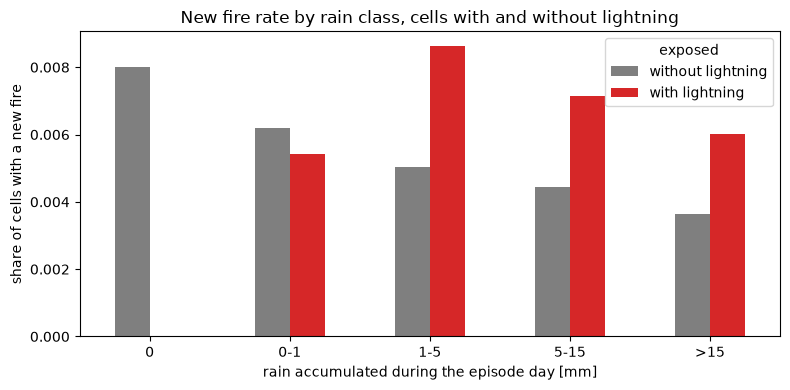

In [29]:
wet = table.assign(wet=table.h61_precip > 1)
groups = table.groupby(table.exposed.astype(bool))
summary = pd.DataFrame({
    "cell episodes": groups.size(),
    "new fire rate": groups.fire_new.mean(),
    "median rain [mm]": groups.h61_precip.median(),
    "share above 1 mm": wet.groupby(wet.exposed.astype(bool)).wet.mean(),
    "median observed slots per fire pixel": groups.obs_per_pixel.median(),
})
summary.index = ["without lightning", "with lightning"]
display(summary.round(3))

rates = (table.groupby(["rain_class", table.exposed.astype(bool)], observed=True).fire_new.mean()
         .unstack().rename(columns={False: "without lightning", True: "with lightning"}))
ax = rates.plot.bar(figsize=(8, 4), color=["tab:grey", "tab:red"], rot=0)
ax.set_xlabel("rain accumulated during the episode day [mm]")
ax.set_ylabel("share of cells with a new fire")
ax.set_title("New fire rate by rain class, cells with and without lightning")
plt.tight_layout()

## RQ1: is lightning followed by more new fires?

The relative risk compares two proportions: the share of cells with lightning that had a new fire and
the share of cells without lightning that had one. The **Mantel-Haenszel estimator** (Mantel and
Haenszel, 1959) computes that comparison inside each stratum first and then combines the strata, each
weighted by its number of exposed and unexposed cells. The strata here are the cell and the rain
class, for the reasons given above, so cells are only ever compared with cells that share their
location and the rain they received. The crude relative risk, which compares the two groups as they
come, is printed next to it.

The interval comes from a **cluster bootstrap**: whole episodes are resampled with replacement and
the estimate is recomputed each time. Cells of the same episode are not independent, because they
share the same storm and the same weather, so the episode, not the cell, is the unit that is
resampled. The 95 % interval is the range between the 2.5 and 97.5 percentiles of the resampled
estimates, and H0 is rejected only if that whole range lies above 1.

exposed cells: 18147, new fire rate 0.0067
unexposed cells: 162409, new fire rate 0.0070
crude relative risk: 0.96
Mantel-Haenszel relative risk, stratified by cell and rain class: 1.38, 95 % interval 0.83 to 1.99


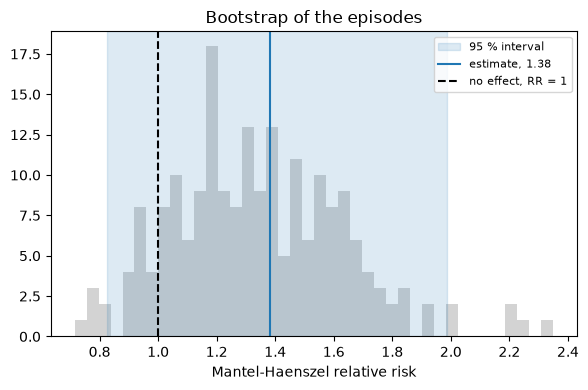

In [30]:
def mantel_haenszel_rr(df):
    """Relative risk of the exposed cells, pooled over the strata of the study design."""
    s = df.assign(n1=df.exposed, n0=1 - df.exposed,
                  a=df.fire_new * df.exposed, c=df.fire_new * (1 - df.exposed)) \
          .groupby(STRATA, observed=True)[["a", "c", "n1", "n0"]].sum()
    n = s.n1 + s.n0
    return (s.a * s.n0 / n).sum() / (s.c * s.n1 / n).sum()

rng = np.random.default_rng(SEED)
episodes = [g for _, g in table.groupby("episode")]

rr = mantel_haenszel_rr(table)
boot = [mantel_haenszel_rr(pd.concat([episodes[i] for i in rng.integers(0, len(episodes), len(episodes))]))
        for _ in range(N_BOOT)]
low, high = np.nanpercentile(boot, [2.5, 97.5])

n1, n0 = table.exposed.sum(), (1 - table.exposed).sum()
a, c = (table.fire_new * table.exposed).sum(), (table.fire_new * (1 - table.exposed)).sum()
print(f"exposed cells: {int(n1)}, new fire rate {a / n1:.4f}")
print(f"unexposed cells: {int(n0)}, new fire rate {c / n0:.4f}")
print(f"crude relative risk: {(a / n1) / (c / n0):.2f}")
print(f"Mantel-Haenszel relative risk, stratified by cell and rain class: "
      f"{rr:.2f}, 95 % interval {low:.2f} to {high:.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(np.asarray(boot)[np.isfinite(boot)], bins=40, color="lightgrey")
ax.axvspan(low, high, color="tab:blue", alpha=0.15, label="95 % interval")
ax.axvline(rr, color="tab:blue", label=f"estimate, {rr:.2f}")
ax.axvline(1, color="black", ls="--", label="no effect, RR = 1")
ax.set_xlabel("Mantel-Haenszel relative risk")
ax.set_title("Bootstrap of the episodes")
ax.legend(fontsize=8)
plt.tight_layout()

### Answer to RQ1

**Cells hit by lightning were followed by more new fires than comparable cells, but one season is not
enough to confirm it.** Compared within the same cell and the same rain class, the Mantel-Haenszel
relative risk is 1.38, with a 95 % interval from 0.83 to 1.99. The estimate says that a new fire was
about 38 % more likely in a cell where lightning fell than in the same cell under similar rain
without lightning. The interval includes 1, so H0 is not rejected: the data are also compatible with
no effect at all.

**The crude comparison and the stratified one.** Taken as they come, the two groups have almost the
same new fire rate, 0.67 % with lightning and 0.70 % without, and the crude relative risk is 0.96.
The two groups also differ in other ways, as the table above shows. Cells with lightning received a
median of 9.2 mm of rain during the episode day, against none in cells without it, and 86 % of them
received more than 1 mm, against 18 %. They were also observed less: 222 observable slots per fire
pixel, against 307. Once each cell is compared with itself, within the same rain class, the relative
risk is 1.38.

**The effect in number of fires.** There are 122 new fires in cells with lightning. With a relative
risk of 1.38, about 34 of them are in excess of the rate the same cells show without lightning, and
the other 88 match that rate. The interval of the relative risk translates into a range for that
excess: from none at its lower end, 0.83, to about 61 at its upper end, 1.99. With one season the
range remains wide, and the number of fires is what limits the answer.

## RQ2: what makes a flash start a fire?

**The sample.** RQ2 uses only the cells hit by lightning. In each of them the outcome is the same as
in RQ1: a new fire in the label window, or none. Cells missing any feature are left out; the GII is
the usual cause, because it is only computed where the sky was clear before the storm. The cell below
prints how many cells remain.

**The features.** Thirteen features describe each cell, in five groups: the rain of the episode day
(`h61_precip`); the atmosphere before the storm (`gii_k_index`, `gii_lifted_index`,
`gii_prec_water_total`); the dryness of the fuel (`frm_ffmc`, `frm_dmc`, `frm_dc`, `frm_fwi`); the
flashes (`lfl_flash_count`, `lfl_duration_mean`, `lfl_footprint_mean`, `lfl_events_per_flash`); and
the tree cover (`lc_trees`). The flash count is taken on a logarithmic scale, because a few cells
collect hundreds of flashes.

**The models.** Two models are fitted. The main one is a **logistic regression** on standardised
features. Each of its coefficients is reported as an odds ratio: the factor by which the odds of a new
fire change when one feature rises by one standard deviation and the others stay fixed. The second is
**XGBoost**, a gradient boosted tree model that can capture non linear effects and interactions. Its SHAP contributions split the prediction of each cell among the features, and their average size
ranks the features by how much they influence the model.

**Training.** Both models are trained on the data as they are, without class weights, so their
outputs can be read as probabilities.

**Validation.** Each model is trained on 36 episodes and tested on the one left out, 37 times, so
cells of the same episode are never used for training and testing at once.

**Scores.** Two scores summarise the predictions. The **AUC-PR**, the area under the precision recall
curve, measures how well the model places the cells that burned above those that did not; a model
without skill scores the prevalence, the share of cells with a fire. The **Brier score** is the mean
squared error of the predicted probabilities: lower is better. Accuracy is not used, because with
fewer than one cell in a hundred burning, a model that always answers "no fire" is almost always right
and has learned nothing.

In [31]:
hit = table[table.exposed == 1].copy()
hit["lfl_flash_count"] = np.log1p(hit.lfl_flash_count)
complete = hit[FEATURES].notna().all(axis=1)
print(f"cells hit by lightning: {len(hit)} | with every feature: {int(complete.sum())} | "
      f"new fires among them: {int(hit.fire_new[complete].sum())}")

hit = hit[complete]
X_rq2, y_rq2, groups_rq2 = hit[FEATURES], hit.fire_new.astype(int), hit.episode

def logistic():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))

def boosted():
    return XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                         random_state=SEED)

cells hit by lightning: 18147 | with every feature: 15723 | new fires among them: 105


In [32]:
oof = pd.DataFrame(index=hit.index, columns=["logistic", "xgboost"], dtype=float)
for train, test in LeaveOneGroupOut().split(X_rq2, y_rq2, groups_rq2):
    X_train, y_train = X_rq2.iloc[train], y_rq2.iloc[train]
    oof.iloc[test, 0] = logistic().fit(X_train, y_train).predict_proba(X_rq2.iloc[test])[:, 1]
    oof.iloc[test, 1] = boosted().fit(X_train, y_train).predict_proba(X_rq2.iloc[test])[:, 1]

prevalence = y_rq2.mean()
scores = pd.DataFrame({m: {"AUC-PR": average_precision_score(y_rq2, p), "Brier": brier_score_loss(y_rq2, p)}
                       for m, p in oof.items()}).T
scores.loc["no skill (prevalence)"] = [prevalence, prevalence * (1 - prevalence)]
scores.round(4)

,AUC-PR,Brier
logistic,0.0057,0.0068
xgboost,0.0091,0.0067
no skill (prevalence),0.0067,0.0066


### Effects: odds ratios and SHAP contributions

The logistic regression is refitted on all the episodes to estimate the odds ratios, and their 95 %
intervals come from the same cluster bootstrap of episodes as the relative risk. XGBoost is refitted
on all the episodes too, and its SHAP contributions, computed by XGBoost itself, are averaged in
absolute value over the cells to rank the features by how much they move the predictions.

,odds ratio,2.5 %,97.5 %
h61_precip,1.128,0.732,1.403
gii_k_index,1.019,0.734,1.454
gii_lifted_index,1.295,0.725,1.914
gii_prec_water_total,0.969,0.704,1.274
frm_ffmc,1.258,0.883,1.848
frm_dmc,1.170,0.764,1.990
frm_dc,0.724,0.401,1.037
frm_fwi,0.909,0.583,1.268
lfl_flash_count,0.854,0.648,1.117
lfl_duration_mean,1.039,0.776,1.310


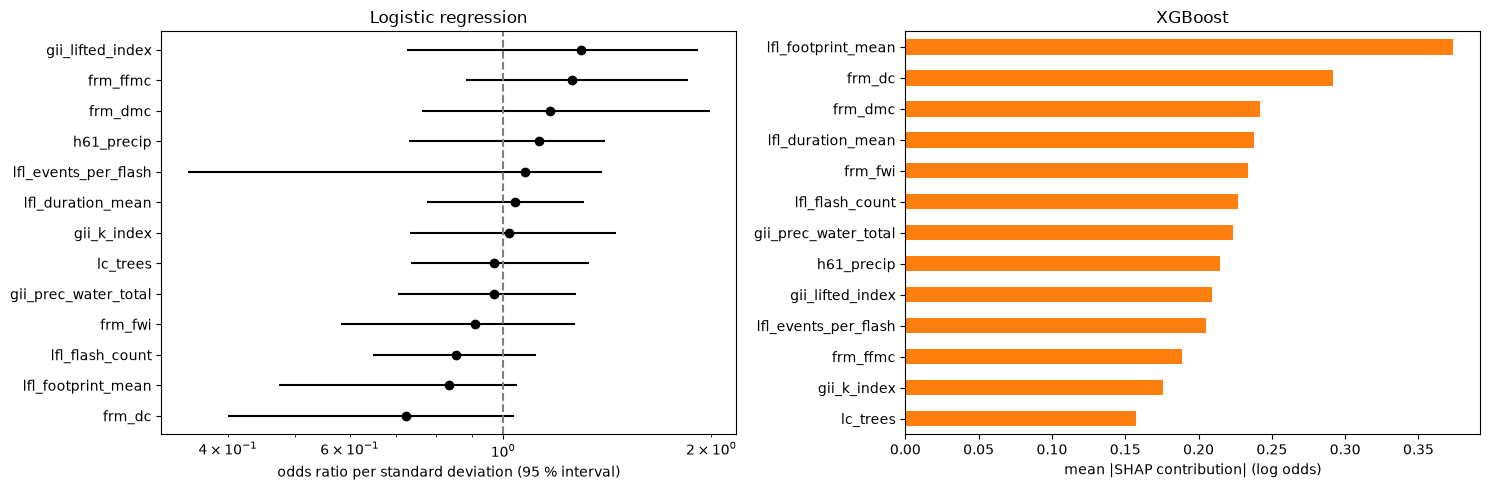

In [33]:
codes = pd.factorize(groups_rq2)[0]
rows = [np.flatnonzero(codes == k) for k in range(codes.max() + 1)]

coef = logistic().fit(X_rq2, y_rq2)[-1].coef_[0]
boot_coef = []
for _ in range(N_BOOT):
    idx = np.concatenate([rows[k] for k in rng.integers(0, len(rows), len(rows))])
    boot_coef.append(logistic().fit(X_rq2.iloc[idx], y_rq2.iloc[idx])[-1].coef_[0])
ci_low, ci_high = np.percentile(boot_coef, [2.5, 97.5], axis=0)
odds = pd.DataFrame({"odds ratio": np.exp(coef), "2.5 %": np.exp(ci_low), "97.5 %": np.exp(ci_high)}, index=FEATURES)
display(odds.round(3))

model = boosted().fit(X_rq2, y_rq2)
shap = model.get_booster().predict(DMatrix(X_rq2), pred_contribs=True)[:, :-1]
importance = pd.Series(np.abs(shap).mean(axis=0), index=FEATURES).sort_values()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
o = odds.sort_values("odds ratio")
ax1.errorbar(o["odds ratio"], range(len(o)), fmt="o", color="k",
             xerr=[o["odds ratio"] - o["2.5 %"], o["97.5 %"] - o["odds ratio"]])
ax1.axvline(1, ls="--", color="grey")
ax1.set_xscale("log")
ax1.set_yticks(range(len(o)), o.index)
ax1.set_xlabel("odds ratio per standard deviation (95 % interval)")
ax1.set_title("Logistic regression")
importance.plot.barh(ax=ax2, color="tab:orange")
ax2.set_xlabel("mean |SHAP contribution| (log odds)")
ax2.set_title("XGBoost")
plt.tight_layout()

An odds ratio above 1 means that the odds of a new fire rise with the feature, below 1 that they fall,
and an interval that crosses 1 means the data cannot tell the direction. Features that carry similar
information share their effect and widen each other's intervals: the four fuel codes are parts of the
same system, and the K index and the lifted index both measure instability. The SHAP ranking of XGBoost
does not assume linear effects, so a feature that is strong in both panels is a robust result, and one
that is strong in only one of them is worth a closer look.

### Answer to RQ2

**No condition measured makes a new fire more or less likely in a way this season can confirm.** The
models do not tell apart the cells that burned from those that did not. The logistic regression
reaches an AUC-PR of 0.0057 and XGBoost 0.0091, while a model without skill reaches 0.0067. Their
Brier scores, 0.0068 and 0.0067, are equal to that of the reference, 0.0066. Every 95 % interval of
the odds ratios includes 1. The one closest to an effect is the Drought Code, 0.72 per standard
deviation, with an interval from 0.40 to 1.04.

**A likely reason is the label.** At the central estimate of RQ1, about 28 % of the fires in cells
hit by lightning are in excess of what those cells had without lightning. So roughly three out of four
of the 105 fires used here are fires that the same cells also have without a storm. The model sees
them all as positives, and any effect of the rain, the atmosphere or the fuel on a lightning ignition
is mixed with the rest. Telling them apart would need the cause of each fire, which no satellite
product provides, or more seasons.

**What the result shows** is how much one season can say. The features are those the literature links
to lightning ignition, no episode is used for training and testing at once, and the models are
trained on the real prevalence. The absence of signal comes from the data, not from the setup.

## RQ3: once a fire starts, what explains its energy?

**The question.** RQ1 and RQ2 ask where a new fire appears. RQ3 asks how much energy it releases once
it has appeared.

**The sample.** Every new fire of the sample enters, with or without lightning. Fires missing any
feature are left out.

**The target.** The energy of a fire is measured as the sum of the Fire Radiative Power of all its
detections during the label window, in (MWatio). It ranges from a single detection of a few (MWats) to fires
seen in hundreds of slots, so it is modelled on a logarithmic scale.

**The features.** Ten features, all defined in every cell of the grid, so that fires with and without
lightning enter the same model: the rain, the three instability indices, the four codes of the Fire
Risk Map, the number of flashes (zero where there were none, on a logarithmic scale) and the tree
cover. The other flash descriptors are left out, because they only exist where a flash fell.

**The models.** The main model is a **ridge regression** on standardised features: a linear
regression with a small penalty on large coefficients, which keeps them stable when features overlap,
as the four codes of the Fire Risk Map do. On these data an ordinary linear regression gives the same
coefficients. Each coefficient is the change in log summed FRP when one feature rises by one standard
deviation and the others stay fixed. **XGBoost** is fitted as a contrast.

**Validation and scores.** Both models are validated leaving one episode out, as in RQ2. Two scores
summarise the predictions. The **coefficient of determination**, R², is the share of the variance of
the log energy that the model explains. The **Spearman rank correlation** between observed and
predicted energy measures whether the model puts the fires in the right order, even when it cannot
predict the size of each one.

In [34]:
burned = table[table.fire_new == 1].dropna(subset=["frp_sum"]).copy()
burned["lfl_flash_count"] = np.log1p(burned.lfl_flash_count)
burned["log_frp"] = np.log1p(burned.frp_sum)
complete3 = burned[FEATURES_ALL].notna().all(axis=1)
print(f"new fires: {len(burned)} | with every feature: {int(complete3.sum())}")
print(burned.frp_sum[complete3].describe(percentiles=[0.25, 0.5, 0.75]).round(1).to_string())

burned = burned[complete3]
X_rq3, y_rq3, groups_rq3 = burned[FEATURES_ALL], burned.log_frp, burned.episode

def ridge():
    return make_pipeline(StandardScaler(), Ridge())

def boosted_regressor():
    return XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
                        random_state=SEED)

oof3 = pd.DataFrame(index=burned.index, columns=["ridge", "xgboost"], dtype=float)
for train, test in LeaveOneGroupOut().split(X_rq3, y_rq3, groups_rq3):
    X_train, y_train = X_rq3.iloc[train], y_rq3.iloc[train]
    oof3.iloc[test, 0] = ridge().fit(X_train, y_train).predict(X_rq3.iloc[test])
    oof3.iloc[test, 1] = boosted_regressor().fit(X_train, y_train).predict(X_rq3.iloc[test])

pd.DataFrame({m: {"R2": r2_score(y_rq3, p), "Spearman": spearmanr(y_rq3, p).statistic}
              for m, p in oof3.items()}).T.round(3)

new fires: 1256 | with every feature: 1132
count      1132.0
mean       5931.8
std       35993.7
min           3.2
25%          11.6
50%          44.0
75%         427.8
max      706551.1


,R2,Spearman
ridge,0.092,0.33
xgboost,0.073,0.29


,effect,2.5 %,97.5 %
h61_precip,-0.101,-0.278,0.081
gii_k_index,0.114,-0.161,0.301
gii_lifted_index,-0.165,-0.422,0.087
gii_prec_water_total,-0.198,-0.407,0.024
frm_ffmc,0.337,0.047,0.565
frm_dmc,0.264,0.039,0.489
frm_dc,-0.479,-0.659,-0.240
frm_fwi,0.444,0.145,0.811
lfl_flash_count,-0.159,-0.337,0.044
lc_trees,-0.105,-0.323,0.085


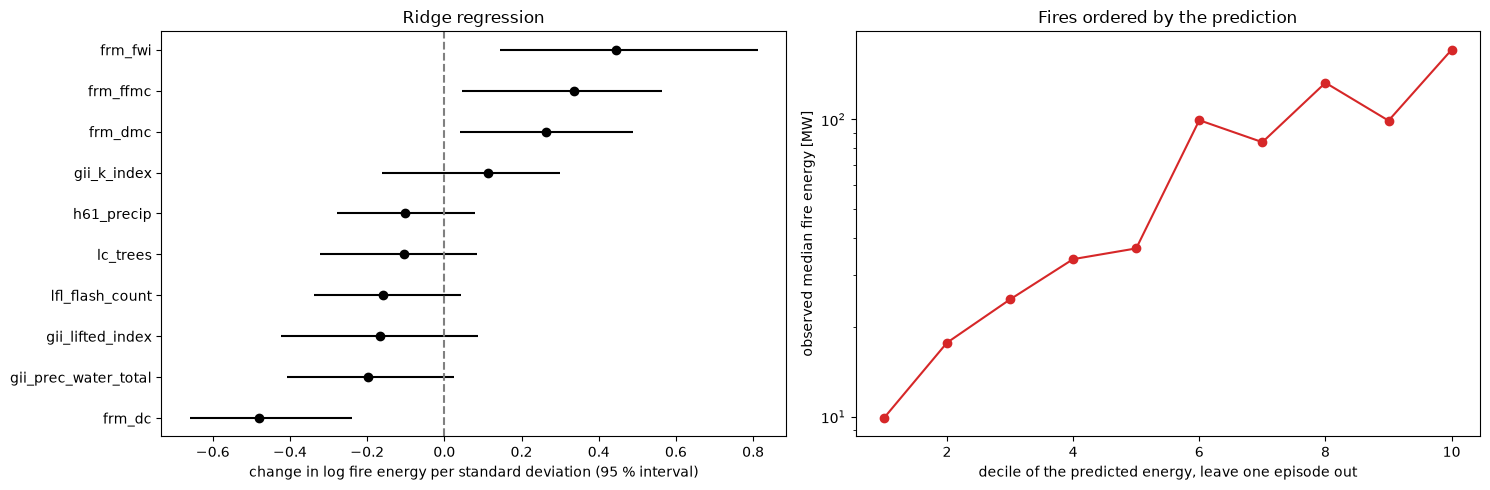

In [35]:
codes3 = pd.factorize(groups_rq3)[0]
rows3 = [np.flatnonzero(codes3 == k) for k in range(codes3.max() + 1)]

coef3 = ridge().fit(X_rq3, y_rq3)[-1].coef_
boot3 = []
for _ in range(N_BOOT):
    idx = np.concatenate([rows3[k] for k in rng.integers(0, len(rows3), len(rows3))])
    boot3.append(ridge().fit(X_rq3.iloc[idx], y_rq3.iloc[idx])[-1].coef_)
lo3, hi3 = np.percentile(boot3, [2.5, 97.5], axis=0)
effects = pd.DataFrame({"effect": coef3, "2.5 %": lo3, "97.5 %": hi3}, index=FEATURES_ALL)
display(effects.round(3))

best = oof3.ridge
deciles = pd.qcut(best, 10, labels=False, duplicates="drop")
observed_by_decile = burned.frp_sum.groupby(deciles).median()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
e = effects.sort_values("effect")
ax1.errorbar(e["effect"], range(len(e)), fmt="o", color="k",
             xerr=[e["effect"] - e["2.5 %"], e["97.5 %"] - e["effect"]])
ax1.axvline(0, ls="--", color="grey")
ax1.set_yticks(range(len(e)), e.index)
ax1.set_xlabel("change in log fire energy per standard deviation (95 % interval)")
ax1.set_title("Ridge regression")
ax2.plot(range(1, len(observed_by_decile) + 1), observed_by_decile.values, "o-", color="tab:red")
ax2.set_yscale("log")
ax2.set_xlabel("decile of the predicted energy, leave one episode out")
ax2.set_ylabel("observed median fire energy [MW]")
ax2.set_title("Fires ordered by the prediction")
plt.tight_layout()

### Answer to RQ3

**The fire danger and the weather of the episode explain about 9 % of the variation in the energy of
the new fires.** Validated on episodes the model never saw, the ridge regression reaches a coefficient
of determination of 0.09 on the logarithm of the summed FRP, and XGBoost 0.07. The remaining variation
is not explained by the features of the cube.

**That share comes from the fire danger.** The four codes of the Fire Risk Map are the only features
with an effect the season confirms. When they rise by one standard deviation, the log summed FRP rises
by 0.44 for the Fire Weather Index (interval 0.15 to 0.81), by 0.34 for the Fine Fuel Moisture Code
(0.05 to 0.57) and by 0.26 for the Duff Moisture Code (0.04 to 0.49): fires on drier fuel release more
energy. The Drought Code has the largest effect, in the opposite direction: −0.48 (−0.66 to −0.24).

**The weather adds nothing that can be confirmed.** The intervals of the rain and of the three
instability indices all cross zero, and so do those of the number of flashes and the tree cover.

**Small as it is, that 9 % is enough to order the fires.** The Spearman rank correlation between
observed and predicted summed FRP is 0.33, so fires predicted to be larger do tend to be larger. The
right panel shows it: the median summed FRP rises from the lowest decile of the prediction to the
highest.


# Notes from the campaign

**Gaps in the archives.** Some slots of the Lightning Imager, the GII and the FRP-Pixel product were
never produced. None of them is filled or interpolated. A missing GII slot is skipped, and the last
clear value is taken from the slots that exist; if no slot exists in the window, the GII layers of
that episode are NaN. A missing FRP-Pixel slot counts as not observed. A missing day of the fire
archive leaves incomplete the prior window of the episodes that need it, and the cube records this in
`prior_complete`.

**The size of the cell.** The pipeline runs at any resolution; 10 km is a choice for this case. The
fuel and rain products have pixels of about 3 km and the fire pixels measure 1.3 to 1.7 km² over
Iberia, so a 10 km cell holds several pixels of every product.

**The scope of the readers.** The three readers are complete DEFAIR plugins: they read from any
source that `open_file` supports, declare their geometry, and are used by the same DEFAIR calls as the
built-in readers. They are not part of the DEFAIR distribution, and they cover only what this case
needs: the five variables of the Fire Risk Map, the daily H SAF precipitation, and the Iberian window
of the FRP-Pixel product.

## Conclusions

This notebook took six products from four providers to three answers, and on the way it showed four
things about working with DEFAIR. **The framework can be extended** Three products
without a reader were brought in with three small plugins, registered through a standard entry point
and used exactly like the official readers. **Heterogeneous sources, one grid.** Gridded and point
products, geostationary and projected, end up as layers of the same cells through the same read, crop,
reproject and align sequence. **The cube is the handover.** One `open_zarr` call is the whole interface
between the data pipeline and the analysis, and the same cube answers three questions that need three
different methods. **An AI ready cube supports honest statistics.** Because every cell carries its
label, its identity, its rain, its observability and its episode, the relative risk can be estimated
between comparable cells, the models validated without mixing episodes, every cell that could not be
observed kept out of the sample instead of being counted as a negative, and each fire counted once
even when the windows of two episodes overlap.

**What the data say.** Cells hit by lightning had about 38 % more new fires than the same cells under
similar rain without lightning, but one season does not confirm it (RQ1: relative risk 1.38, interval
0.83 to 1.99). Among those cells, no condition measured changed the chance of a fire in a way the data
can confirm (RQ2). Once a fire had started, the fire danger of the day explained about 9 % of the
energy it released, enough to rank the fires (RQ3).

**Why the ignition questions stay open.** Lightning starts only about 5 % of the forest fires of the
region ([Pérez-Invernón et al., 2021](https://doi.org/10.5194/acp-21-17529-2021)), and the label counts
every new fire, whatever its cause. The effect of the lightning is therefore measured on a small part
of the fires. More seasons, which the same pipeline can process, or records of fire causes would
sharpen it.

**Association, not causation.** The results describe an association between lightning and new fire
detections during one season, not the cause of any single fire. The limits of the data are listed in
the assumptions.


## Resources and references

**Scientific literature**

DaCamara, C. C., Calado, T. J., Ermida, S. L., Trigo, I. F., Amraoui, M., & Turkman, K. F. (2014). Calibration of the Fire Weather Index over Mediterranean Europe based on fire activity retrieved from MSG satellite imagery. *International Journal of Wildland Fire*, 23(7), 945 to 958. [https://doi.org/10.1071/WF13157](https://doi.org/10.1071/WF13157)

Enno, S.-E., Viticchié, B., Navia, D., & Grandell, J. (2026). First year of Meteosat Third Generation Lightning Imager observations. *EGUsphere* preprint, under review for *Atmospheric Measurement Techniques*. [https://doi.org/10.5194/egusphere-2026-3386](https://doi.org/10.5194/egusphere-2026-3386)

Mantel, N., & Haenszel, W. (1959). Statistical aspects of the analysis of data from retrospective studies of disease. *Journal of the National Cancer Institute*, 22(4), 719 to 748. [https://doi.org/10.1093/jnci/22.4.719](https://doi.org/10.1093/jnci/22.4.719)

Moris, J. V., Conedera, M., Nisi, L., Bernardi, M., Cesti, G., & Pezzatti, G. B. (2020). Lightning-caused fires in the Alps: Identifying the igniting strokes. *Agricultural and Forest Meteorology*, 290, 107990. [https://doi.org/10.1016/j.agrformet.2020.107990](https://doi.org/10.1016/j.agrformet.2020.107990)

Moris, J. V., Álvarez-Álvarez, P., Conedera, M., et al. (2023). A global database on holdover time of lightning-ignited wildfires. *Earth System Science Data*, 15, 1151 to 1163. [https://doi.org/10.5194/essd-15-1151-2023](https://doi.org/10.5194/essd-15-1151-2023)

Pérez-Invernón, F. J., Huntrieser, H., Soler, S., Gordillo-Vázquez, F. J., Pineda, N., Navarro-González, J., Reglero, V., Montanyà, J., van der Velde, O., & Koutsias, N. (2021). Lightning-ignited wildfires and long continuing current lightning in the Mediterranean Basin: preferential meteorological conditions. *Atmospheric Chemistry and Physics*, 21, 17529 to 17557. [https://doi.org/10.5194/acp-21-17529-2021](https://doi.org/10.5194/acp-21-17529-2021)

Pineda, N., & Rigo, T. (2017). The rainfall factor in lightning-ignited wildfires in Catalonia. *Agricultural and Forest Meteorology*, 239, 249 to 263. [https://doi.org/10.1016/j.agrformet.2017.03.016](https://doi.org/10.1016/j.agrformet.2017.03.016)

Rodrigues, M., Jiménez-Ruano, A., Gelabert, P. J., Resco de Dios, V., Torres, L., Ribalaygua, J., & Vega-García, C. (2023). Modelling the daily probability of lightning-caused ignition in the Iberian Peninsula. *International Journal of Wildland Fire*, 32(3), 351 to 362. [https://doi.org/10.1071/WF22123](https://doi.org/10.1071/WF22123)

Soler, A., Pineda, N., San Segundo, H., Bech, J., & Montanyà, J. (2021). Characterisation of thunderstorms that caused lightning-ignited wildfires. *International Journal of Wildland Fire*, 30(12), 954 to 970. [https://doi.org/10.1071/WF21076](https://doi.org/10.1071/WF21076)

Van Wagner, C. E. (1987). *Development and structure of the Canadian Forest Fire Weather Index System*. Canadian Forestry Service, Forestry Technical Report 35, Ottawa. [https://cfs.nrcan.gc.ca/pubwarehouse/pdfs/19927.pdf](https://cfs.nrcan.gc.ca/pubwarehouse/pdfs/19927.pdf)

Vecín-Arias, D., Castedo-Dorado, F., Ordóñez, C., & Rodríguez-Pérez, J. R. (2016). Biophysical and lightning characteristics drive lightning-induced fire occurrence in the central plateau of the Iberian Peninsula. *Agricultural and Forest Meteorology*, 225, 36 to 47. [https://doi.org/10.1016/j.agrformet.2016.05.003](https://doi.org/10.1016/j.agrformet.2016.05.003)

**Product documentation**

LSA SAF, *Product User Manual for Fire Risk Map, version 2 (FRM2)*, product LSA-504.2, SAF/LAND/IDL/PUM_FRM2/1.0, 2020. LSA SAF, *Product User Manual for the MTG FRP-Pixel product*, SAF/LAND/IPMA/PUM_MTFRP/1.0. LSA SAF, *Product Output Format*, SAF/LAND/IPMA/POF/1.2, available in the [LSA SAF documentation repository](https://nextcloud.lsasvcs.ipma.pt/s/CjtrxjMcYBz5wT7?dir=/PUM-Product_User_Manual). EUMETSAT, *MSG Level 1.5 Image Data Format Description*, EUM/MSG/ICD/105, v8, 2017, [user.eumetsat.int](https://user.eumetsat.int/s3/eup-strapi-media/pdf_ten_05105_msg_img_data_e7c8b315e6.pdf). EUMETSAT, *MTG LI Level 2 Format Specification*, [user.eumetsat.int](https://user.eumetsat.int/s3/eup-strapi-media/MTG_LI_Level_2_Format_Specification_12c067c926.pdf). Pytroll, satpy area definitions, area `msg_seviri_fes_3km`, [satpy/etc/areas.yaml](https://github.com/pytroll/satpy/blob/main/satpy/etc/areas.yaml). The EUMETSAT User Portal describes the MTG products in the [MTG FCI L2 GII data guide](https://user.eumetsat.int/resources/user-guides/mtg-fci-l2-gii-data-guide) and the [MTG LI Level 2 data guide](https://user.eumetsat.int/resources/user-guides/mtg-li-level-2-data-guide). The Copernicus Land Monitoring Service documents the land cover in the [CLCplus Backbone 2023 Product User Manual](https://library.land.copernicus.eu/products/CLCplus_Backbone_2023_PUM_v1.pdf).

**Destination Earth DataLake and DEFAIR**

Data discovery and access use the Harmonised Data Access STAC API at [https://hda.data.destination-earth.eu](https://github.com/destination-earth/DestinE-DataLake-Lab/tree/main/HDA), the DataLake S3 object store at [https://s3.central.data.destination-earth.eu](https://s3.central.data.destination-earth.eu) and the DestinE JupyterHub where this notebook runs. The [DestinE DataLake Lab repository](https://github.com/destination-earth/DestinE-DataLake-Lab) collects the official access notebooks this project builds on. This notebook uses DEFAIR 0.4.0rc3.